In [1]:
 # Required packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

import scipy.sparse as sp


## Data loading

### TR1 and L2

In [2]:
# this has both L2 and TR from previous experiments

df = pd.read_csv("https://raw.githubusercontent.com/happy522/Shining-Through/refs/heads/main/Implementation/TR1%20and%20L2/L2_TR.csv")

df = df.drop(columns=["Unnamed: 0","sentlength","alang","akorp","afile"],axis = "columns")
df = df.rename(columns={"astatus": "dataset_name"})

num_cols = df.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]
print("Numeric feature columns:", numerical_cols)

# Count of L1 per L2
count_per_L2 = df.groupby("dataset_name")["L1"].value_counts().unstack(fill_value=0)

print(count_per_L2)

# Data balancing across entire data set
L2 = df[df['dataset_name'] == 'L2']
TR1 = df[df['dataset_name'] == 'TR']


""" concating lets do it afterwards!
df_balanced_1100 = pd.concat([df_L2, df_TR_downsampled_1100], ignore_index=True)"""




Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']
L1               de     es     fr    it
dataset_name                           
L2             1100   1100   1100  1100
TR            27743  18604  89626  2167


' concating lets do it afterwards!\ndf_balanced_1100 = pd.concat([df_L2, df_TR_downsampled_1100], ignore_index=True)'

### Europarl (TR2)

In [3]:
# Europarl data

TR2 = pd.read_csv("https://raw.githubusercontent.com/happy522/Shining-Through/refs/heads/main/Data%20Generation/Datasets/europarl/europarl_all_data.csv")

TR2 = TR2.drop(columns="sentlength",axis = "columns")
TR2 = TR2.drop(columns=["Unnamed: 0","alang","akorp","afile","astatus"],axis = "columns")


num_cols = TR2.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]
print("Numeric feature columns:", numerical_cols)


Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']


# RQ1: Running Experiments (K-means and NN) individually in TR1, TR2 and L2
(For each data downsample to their minimum value)

- Note: In previous experiments there were warnings regarding ill defined  labels with no predicted samples (which led to confusion matrix omittig such cases)  
- Also I've scaled the features -  it didn't change results that much but now its consistant

## Kmeans

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def run_kmeans_evaluation(df, n_clusters=None, label_col='L1', drop_cols=None, plot=True):

    #df = df.dropna().copy()

    # Separate labels
    y_true = df[label_col].values

    # Drop non-feature columns
    if drop_cols is not None:
        df_features = df.drop(drop_cols, axis=1)
    else:
        df_features = df.drop(columns=[label_col])

    X = df_features.values

    # SCALE FEATURES
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Auto-set clusters = number of classes if not given
    if n_clusters is None:
        n_clusters = len(np.unique(y_true))

    # Fit KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_ids = kmeans.fit_predict(X)

    df['cluster'] = cluster_ids

    cluster_to_label = {}

    for cluster in np.unique(cluster_ids):
        mask = (cluster_ids == cluster)

        if np.sum(mask) == 0:
            continue

        unique_labels, counts = np.unique(y_true[mask], return_counts=True)

        # Assign most frequent label
        cluster_to_label[cluster] = unique_labels[np.argmax(counts)]

    # Map predictions
    y_pred = np.array([cluster_to_label[c] for c in cluster_ids])

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print("Clustering Accuracy:", accuracy)
    labels = sorted(set(y_true) | set(y_pred))

    confusion_matrix = pd.crosstab(
        y_true,
        y_pred,
        rownames=['True'],
        colnames=['Pred']
    ).reindex(index=labels, columns=labels, fill_value=0)
    print(confusion_matrix)

    print("\nClassification Report:\n",
          classification_report(y_true, y_pred, digits=4, zero_division=0))

    # Plot
    if plot:
        plt.figure(figsize=(8,6))
        sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
        plt.title(f'KMeans Confusion Matrix (k={n_clusters})')
        plt.show()

    df = df.drop('cluster', axis=1)

    return df, accuracy, confusion_matrix

### L2

L1
es    1100
de    1100
it    1100
fr    1100
Name: count, dtype: int64
Clustering Accuracy: 0.32295454545454544
Pred   de   es  fr  it
True                  
de    881  219   0   0
es    560  540   0   0
fr    779  321   0   0
it    615  485   0   0

Classification Report:
               precision    recall  f1-score   support

          de     0.3108    0.8009    0.4478      1100
          es     0.3450    0.4909    0.4053      1100
          fr     0.0000    0.0000    0.0000      1100
          it     0.0000    0.0000    0.0000      1100

    accuracy                         0.3230      4400
   macro avg     0.1640    0.3230    0.2133      4400
weighted avg     0.1640    0.3230    0.2133      4400



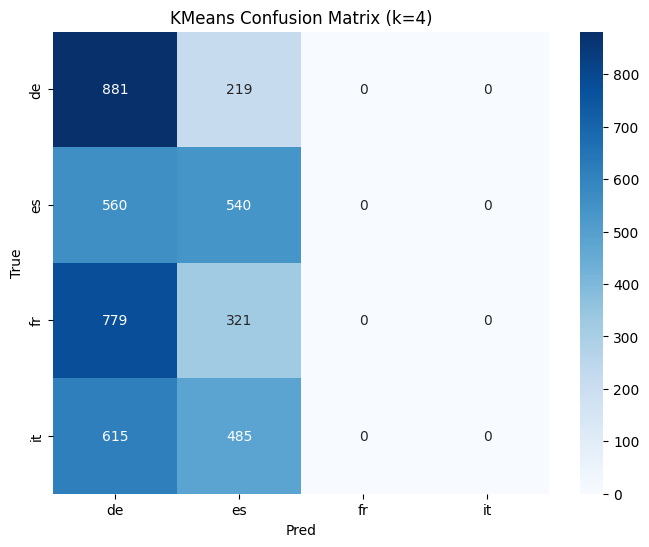

In [5]:
print(L2["L1"].value_counts())

min_count = L2["L1"].value_counts().min()

# Downsample each class to that size
L2 = (
    L2
    .groupby('L1', group_keys=False)
    .sample(n=min_count, random_state=42)
)

L2, acc, cm = run_kmeans_evaluation(L2, n_clusters=4, label_col='L1', drop_cols=['L1',"dataset_name"], plot=True)

### TR1

L1
fr    89626
de    27743
es    18604
it     2167
Name: count, dtype: int64
Clustering Accuracy: 0.3573907009021513
Pred   de   es   fr   it
True                    
de    975  232  565  381
es    836  770  560    1
fr    898  452  816    1
it    325  631  674  529

Classification Report:
               precision    recall  f1-score   support

          de     0.3214    0.4529    0.3759      2153
          es     0.3693    0.3553    0.3622      2167
          fr     0.3120    0.3766    0.3413      2167
          it     0.5800    0.2450    0.3445      2159

    accuracy                         0.3574      8646
   macro avg     0.3957    0.3574    0.3560      8646
weighted avg     0.3956    0.3574    0.3560      8646



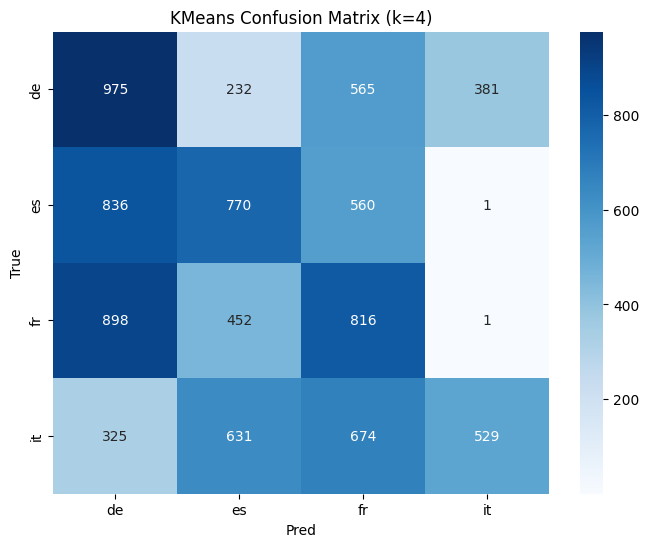

In [6]:
print(TR1["L1"].value_counts())

min_count = TR1["L1"].value_counts().min()

# Downsample each class to that size
TR1 = (
    TR1
    .groupby('L1', group_keys=False)
    .sample(n=min_count, random_state=42)
)
TR1 = TR1.dropna()

TR1, acc, cm = run_kmeans_evaluation(TR1, n_clusters=4, label_col='L1', drop_cols=['L1',"dataset_name"], plot=True)


#### TR2

L1
de    479
fr    476
it    463
es    272
Name: count, dtype: int64
Clustering Accuracy: 0.5257352941176471
Pred   de   es   fr   it
True                    
de    187   55   25    5
es     52  102   67   51
fr     77   30  157    8
it     17   74   55  126

Classification Report:
               precision    recall  f1-score   support

          de     0.5616    0.6875    0.6182       272
          es     0.3908    0.3750    0.3827       272
          fr     0.5164    0.5772    0.5451       272
          it     0.6632    0.4632    0.5455       272

    accuracy                         0.5257      1088
   macro avg     0.5330    0.5257    0.5229      1088
weighted avg     0.5330    0.5257    0.5229      1088



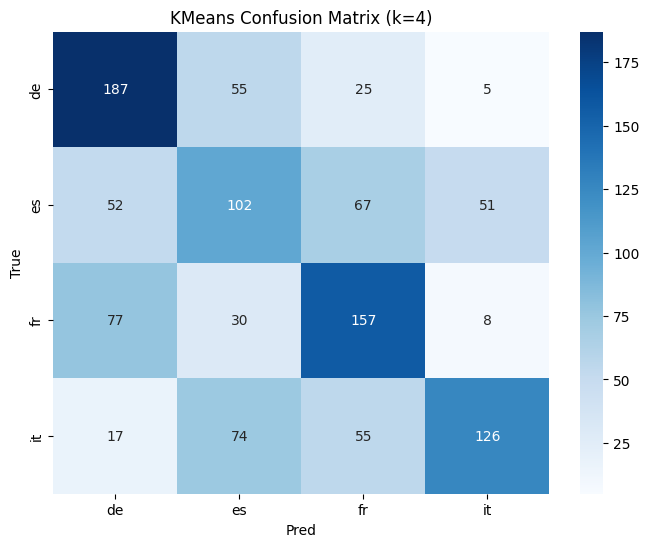

In [7]:
print(TR2["L1"].value_counts())

min_count = TR2["L1"].value_counts().min()

# Downsample each class to that size
TR2 = (
    TR2
    .groupby('L1', group_keys=False)
    .sample(n=min_count, random_state=42)
)


TR2, acc, cm = run_kmeans_evaluation(TR2, n_clusters=4, label_col='L1', drop_cols=['L1'], plot=True)


## NN

In [22]:
import scipy.sparse as sp
from sklearn.metrics import confusion_matrix



def run_nn(df, features, label_col="L1", title="Neural Network"):


    X = df[features].values
    y = df[label_col].values

    if y.dtype.kind in {'O', 'U', 'S'}:  # string/object
        le = LabelEncoder()
        y = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Length: {len(df)}, Train: {len(X_train)}, Test: {len(X_test)}")

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Ensure X is dense float64

    def to_dense_float(a):
        if sp.issparse(a):
            a = a.toarray()
        return np.asarray(a, dtype=np.float64)

    X_train_s = to_dense_float(X_train_s)
    X_test_s  = to_dense_float(X_test_s)


    # Ensure y is a plain 1D array (not sparse, not weird dtype)
    y_train = np.asarray(y_train)
    y_test  = np.asarray(y_test)


    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    mlp.fit(X_train_s, y_train)

    y_pred = mlp.predict(X_test_s)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n===== {title} =====")
    print("Test Accuracy:", accuracy)

    cm = confusion_matrix(y_test, y_pred)

    label_map = {0: "de", 1: "es", 2: "fr", 3: "it"}

    labels = sorted(label_map.keys())
    target_names = [label_map[i] for i in labels]

    print(
        "\nClassification Report:\n",
        classification_report(
            y_test,
            y_pred,
            labels=labels,
            target_names=target_names,
            digits=4
        )
    )

    # The LabelEncoder may re-order classes, so use le.classes_
    # and convert them back to original coded labels
    classes = le.classes_                    # e.g. ["de","es","fr","it"]
    classes_int = le.transform(classes)      # e.g. [0,1,2,3]
    classes_str = [label_map[i] for i in classes_int]

    print("\nConfusion matrix:")
    print(cm)

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=classes_str,
        yticklabels=classes_str
    )
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


    return mlp, accuracy, cm


### L2


===== MLP Classification of L2 dataset(Test set) =====
Test Accuracy: 0.48295454545454547

Classification Report:
               precision    recall  f1-score   support

          de     0.4801    0.6045    0.5352       220
          es     0.4749    0.4727    0.4738       220
          fr     0.4673    0.4227    0.4439       220
          it     0.5135    0.4318    0.4691       220

    accuracy                         0.4830       880
   macro avg     0.4840    0.4830    0.4805       880
weighted avg     0.4840    0.4830    0.4805       880


Confusion matrix:
[[133  30  35  22]
 [ 41 104  40  35]
 [ 59  35  93  33]
 [ 44  50  31  95]]


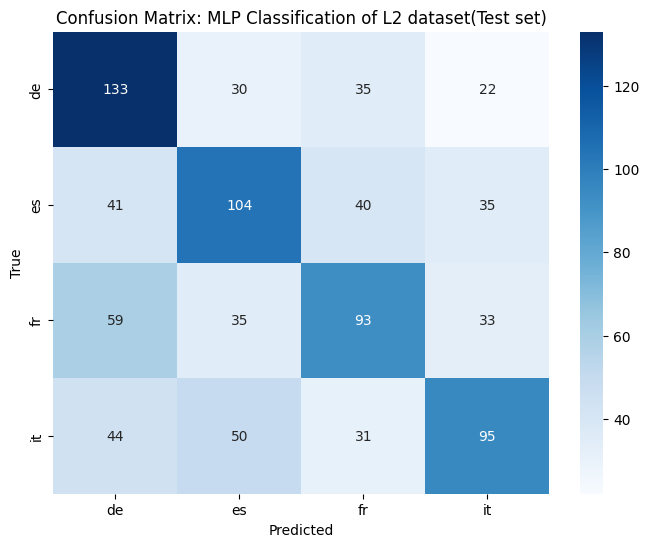

In [9]:
features = L2.drop(columns=['L1',"dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(L2, features, label_col="L1", title="MLP Classification of L2 dataset(Test set)")

### TR1


===== MLP Classification of TR1 dataset(Test set) =====
Test Accuracy: 0.6092485549132948

Classification Report:
               precision    recall  f1-score   support

          de     0.5854    0.4292    0.4953       431
          es     0.5812    0.6843    0.6286       434
          fr     0.6859    0.6305    0.6570       433
          it     0.5921    0.6921    0.6382       432

    accuracy                         0.6092      1730
   macro avg     0.6112    0.6090    0.6048      1730
weighted avg     0.6112    0.6092    0.6049      1730


Confusion matrix:
[[185  74  41 131]
 [ 37 297  60  40]
 [ 41  84 273  35]
 [ 53  56  24 299]]


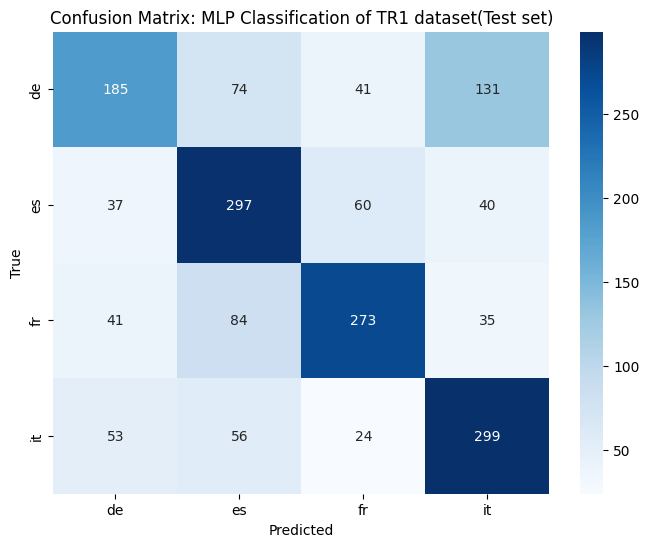

In [10]:
features = TR1.drop(columns=['L1',"dataset_name"]).select_dtypes(include=[np.number]).columns
TR1 = TR1.dropna()
mlp_model, acc, cm = run_nn(TR1, features, label_col="L1", title="MLP Classification of TR1 dataset(Test set)")


===== MLP Classification of TR2 dataset(Test set) =====
Test Accuracy: 0.7614678899082569

Classification Report:
               precision    recall  f1-score   support

          de     0.8226    0.9273    0.8718        55
          es     0.6275    0.5926    0.6095        54
          fr     0.8235    0.7636    0.7925        55
          it     0.7593    0.7593    0.7593        54

    accuracy                         0.7615       218
   macro avg     0.7582    0.7607    0.7583       218
weighted avg     0.7588    0.7615    0.7589       218


Confusion matrix:
[[51  1  3  0]
 [ 5 32  6 11]
 [ 3  8 42  2]
 [ 3 10  0 41]]


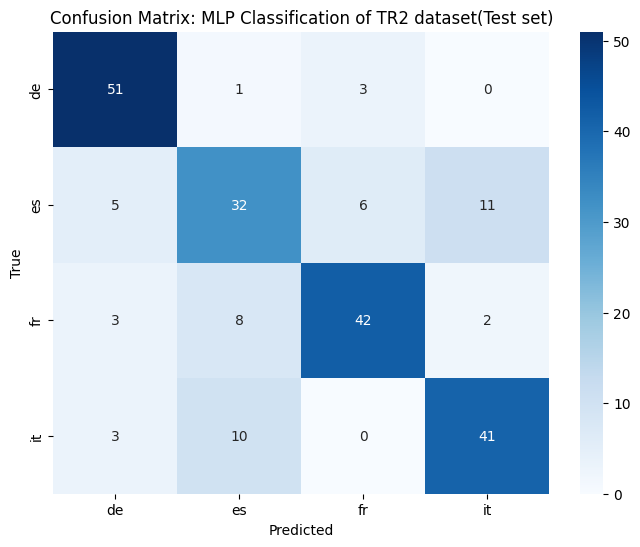

In [11]:
features = TR2.drop(columns=['L1']).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(TR2, features, label_col="L1", title="MLP Classification of TR2 dataset(Test set)")

# Combining all 3 TR1, TR2, L2 then doing KMeans and NN after downsampling

In [12]:
# smallest sample in Europarl is of 272 (Es) hence downsampling every data
"""TR1 = (
    TR1
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)

L2 = (
    L2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)


TR2 = (
    TR2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)"""
TR1["dataset_name"] = "TR1"
TR2["dataset_name"] = "TR2"
L2["dataset_name"] = "L2"


df = pd.concat([TR1, L2, TR2], axis=0, ignore_index=True)

Clustering Accuracy: 0.298995330408943
Pred  de    es    fr    it
True                      
de     0  1035   746  1744
es     0  1072  1081  1386
fr     0   964  1199  1376
it     0   534  1042  1955

Classification Report:
               precision    recall  f1-score   support

          de     0.0000    0.0000    0.0000      3525
          es     0.2974    0.3029    0.3001      3539
          fr     0.2947    0.3388    0.3152      3539
          it     0.3026    0.5537    0.3913      3531

    accuracy                         0.2990     14134
   macro avg     0.2237    0.2988    0.2517     14134
weighted avg     0.2238    0.2990    0.2518     14134



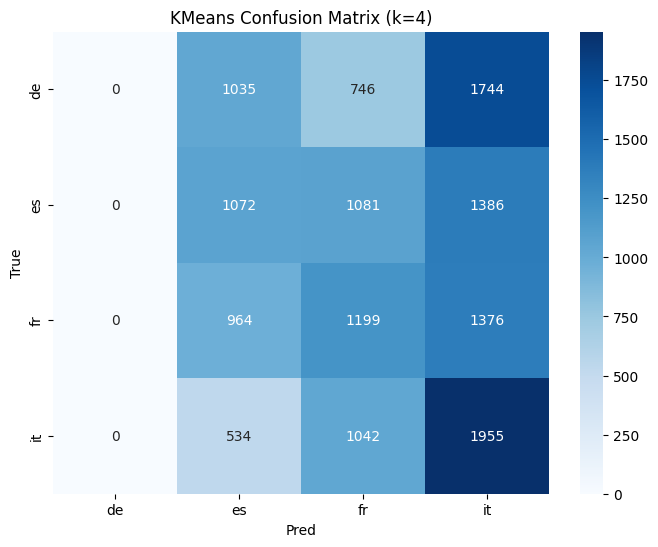

In [13]:
df, acc, cm = run_kmeans_evaluation(df, n_clusters=4, label_col='L1', drop_cols=['L1',"dataset_name"], plot=True)

Length: 3264, Train: 2611, Test: 653

===== MLP Classification of all dataset(Test set) =====
Test Accuracy: 0.557427258805513

Classification Report:
               precision    recall  f1-score   support

          de     0.6215    0.6748    0.6471       163
          es     0.5423    0.4724    0.5049       163
          fr     0.5257    0.5610    0.5428       164
          it     0.5346    0.5215    0.5280       163

    accuracy                         0.5574       653
   macro avg     0.5560    0.5574    0.5557       653
weighted avg     0.5560    0.5574    0.5557       653


Confusion matrix:
[[110  11  25  17]
 [ 22  77  31  33]
 [ 27  21  92  24]
 [ 18  33  27  85]]


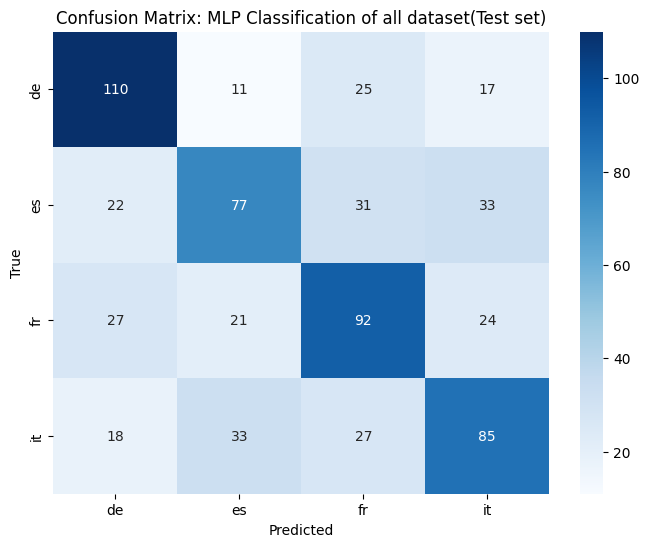

In [23]:
features = df.drop(columns=['L1',"dataset_name"]).select_dtypes(include=[np.number]).columns
#df = df.dropna()
mlp_model, acc, cm = run_nn(df, features, label_col="L1", title="MLP Classification of all dataset(Test set)")

#3 Kmeans for TR1 vs TR2 vs L2

In [25]:
df["dataset_name"].unique()

# smallest sample in Europarl is of 272 (Es) hence downsampling every data
TR1 = (
    TR1
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)

L2 = (
    L2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)


TR2 = (
    TR2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)
TR1["dataset_name"] = "TR1"
TR2["dataset_name"] = "TR2"
L2["dataset_name"] = "L2"


df = pd.concat([TR1, L2, TR2], axis=0, ignore_index=True)

Clustering Accuracy: 0.6522671568627451
Pred    L2   TR1  TR2
True                 
L2    1083     5    0
TR1     42  1046    0
TR2   1078    10    0

Classification Report:
               precision    recall  f1-score   support

          L2     0.4916    0.9954    0.6582      1088
         TR1     0.9859    0.9614    0.9735      1088
         TR2     0.0000    0.0000    0.0000      1088

    accuracy                         0.6523      3264
   macro avg     0.4925    0.6523    0.5439      3264
weighted avg     0.4925    0.6523    0.5439      3264



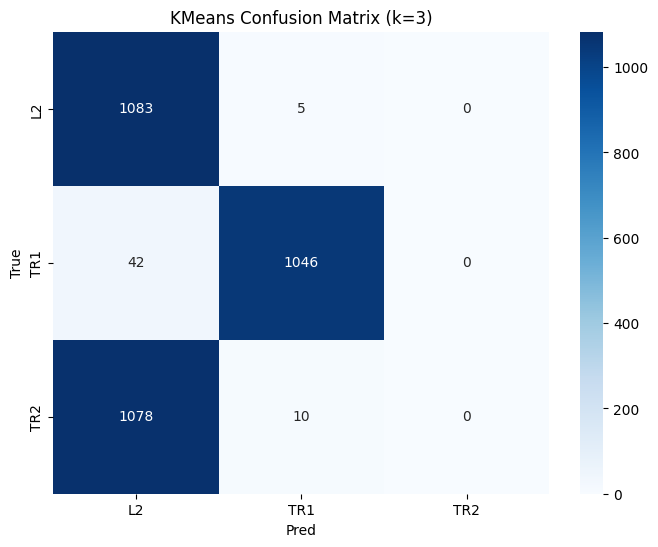

In [26]:
df, acc, cm = run_kmeans_evaluation(df, n_clusters=3, label_col='dataset_name', drop_cols=['L1',"dataset_name"], plot=True)

## NN for 3 clusters

Length: 3264, Train: 2611, Test: 653

===== MLP Classification of all dataset(Test set) =====
Test Accuracy: 0.9770290964777948

Classification Report:
               precision    recall  f1-score   support

          de     0.9552    0.9816    0.9682       217
          es     0.9862    0.9862    0.9862       218
          fr     0.9906    0.9633    0.9767       218
          it     0.0000    0.0000    0.0000         0

    accuracy                         0.9770       653
   macro avg     0.7330    0.7328    0.7328       653
weighted avg     0.9774    0.9770    0.9771       653


Confusion matrix:
[[213   3   1]
 [  2 215   1]
 [  8   0 210]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

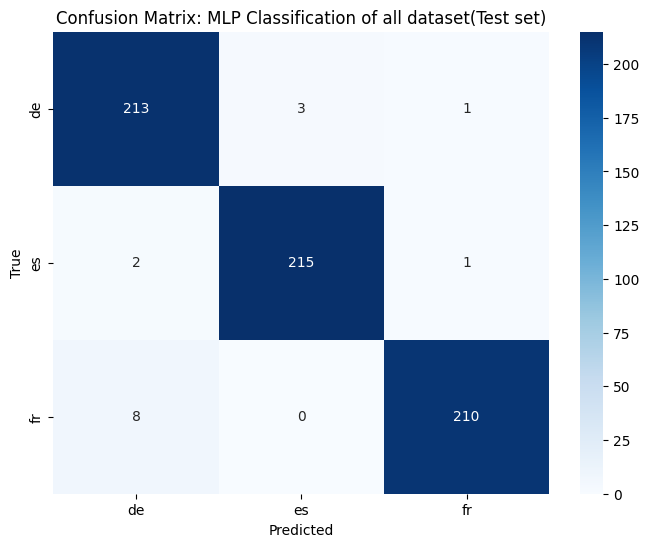

In [27]:
features = df.drop(columns=['L1',"dataset_name"]).select_dtypes(include=[np.number]).columns
#df = df.dropna()
mlp_model, acc, cm = run_nn(df, features, label_col="dataset_name", title="MLP Classification of all dataset(Test set)")

# RQ3: Train on one and test on others - NN
- (L2 -> TR1, TR2)
- (TR1 -> L2, TR2)
- (TR2 -> TR1, L2)

In [28]:
exclude_cols = ["L1", "dataset_name", "L1_num"]

features = [col for col in L2.columns if col not in exclude_cols]

In [29]:
def train_one_test_two(
    train_df,
    test_df,
    features,
    label_col="L1",
    title="Cross Dataset NN",
    plot=True
):

    # -----------------------
    # 1. Split features/labels
    # -----------------------
    X_train = train_df[features].values
    y_train = train_df[label_col].values

    X_test = test_df[features].values
    y_test = test_df[label_col].values

    # -----------------------
    # 2. Label Encoding (fit ONLY on train)
    # -----------------------
    if y_train.dtype.kind in {'O', 'U', 'S'}:
        le = LabelEncoder()
        y_train = le.fit_transform(y_train)
        y_test = le.transform(y_test)
    else:
        le = None

    # -----------------------
    # 3. Handle NaNs (IMPORTANT)
    # -----------------------
    imputer = SimpleImputer(strategy="mean")
    X_train = imputer.fit_transform(X_train)
    X_test  = imputer.transform(X_test)

    # -----------------------
    # 4. Scaling (fit ONLY on train)
    # -----------------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # -----------------------
    # 5. Ensure dense float
    # -----------------------
    def to_dense_float(a):
        if sp.issparse(a):
            a = a.toarray()
        return np.asarray(a, dtype=np.float64)

    X_train = to_dense_float(X_train)
    X_test  = to_dense_float(X_test)

    y_train = np.asarray(y_train)
    y_test  = np.asarray(y_test)

    # -----------------------
    # 6. Model
    # -----------------------
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )


    mlp.fit(X_train, y_train)

    # -----------------------
    # 7. Prediction
    # -----------------------
    y_pred = mlp.predict(X_test)

    # -----------------------
    # 8. Metrics
    # -----------------------
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n===== {title} =====")
    print("Test Accuracy:", accuracy)

    print("\nClassification Report:\n",
          classification_report(y_test, y_pred, digits=4, zero_division=0))

    # -----------------------
    # 9. Confusion Matrix (clean + aligned)
    # -----------------------
    labels = sorted(set(y_test) | set(y_pred))

    cm_df = pd.crosstab(
        y_test,
        y_pred,
        rownames=['True'],
        colnames=['Pred']
    ).reindex(index=labels, columns=labels, fill_value=0)

    # Optional: map labels to readable names
    if le is not None:
        class_names = le.inverse_transform(labels)
        cm_df.index = class_names
        cm_df.columns = class_names

    print("\nConfusion Matrix:\n", cm_df)

    # -----------------------
    # 10. Plot
    # -----------------------
    if plot:
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm_df,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=cm_df.columns,
            yticklabels=cm_df.index
        )
        plt.title(f"Confusion Matrix: {title}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

    return mlp, accuracy, cm_df


===== TR1 -> L2 =====
Test Accuracy: 0.24540441176470587

Classification Report:
               precision    recall  f1-score   support

           0     0.3214    0.0662    0.1098       272
           1     0.2378    0.4301    0.3063       272
           2     0.4082    0.0735    0.1246       272
           3     0.2281    0.4118    0.2936       272

    accuracy                         0.2454      1088
   macro avg     0.2989    0.2454    0.2086      1088
weighted avg     0.2989    0.2454    0.2086      1088


Confusion Matrix:
     de   es  fr   it
de  18  125   6  123
es  11  117  10  134
fr  18  112  20  122
it   9  138  13  112


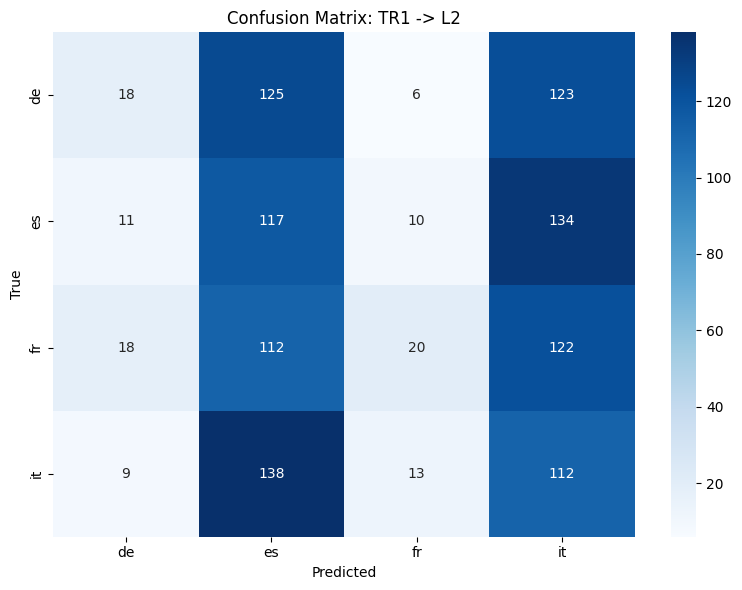

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.24540441176470587,
     de   es  fr   it
 de  18  125   6  123
 es  11  117  10  134
 fr  18  112  20  122
 it   9  138  13  112)

In [ ]:
train_one_test_two(
    TR1,
    L2,
    features,
    title="TR1 -> L2"
)


===== TR1 -> TR2 =====
Test Accuracy: 0.2545955882352941

Classification Report:
               precision    recall  f1-score   support

           0     0.6667    0.0147    0.0288       272
           1     0.2461    0.9265    0.3889       272
           2     0.0000    0.0000    0.0000       272
           3     0.3684    0.0772    0.1277       272

    accuracy                         0.2546      1088
   macro avg     0.3203    0.2546    0.1363      1088
weighted avg     0.3203    0.2546    0.1363      1088


Confusion Matrix:
     de   es  fr  it
de   4  261   0   7
es   2  252   0  18
fr   0  261   0  11
it   0  250   1  21


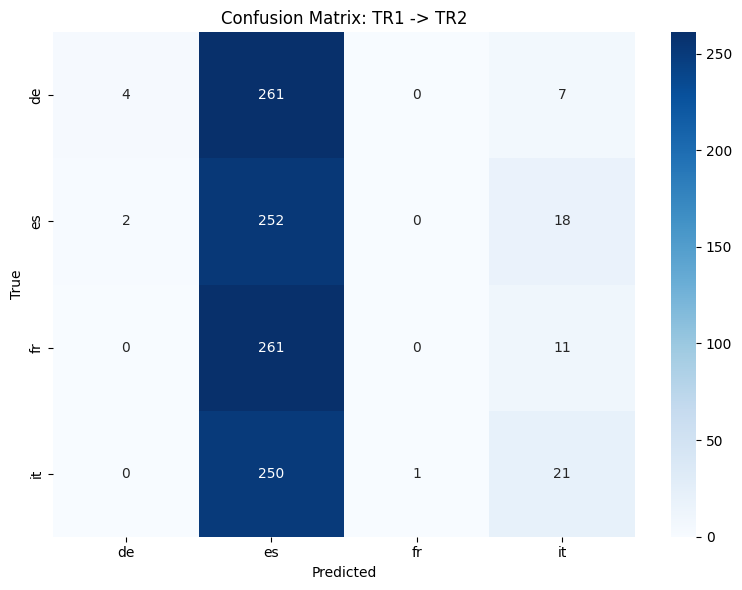

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.2545955882352941,
     de   es  fr  it
 de   4  261   0   7
 es   2  252   0  18
 fr   0  261   0  11
 it   0  250   1  21)

In [ ]:
train_one_test_two(
    TR1,
    TR2,
    features,
    title="TR1 -> TR2"
)


===== TR2 -> L2 =====
Test Accuracy: 0.32628676470588236

Classification Report:
               precision    recall  f1-score   support

           0     0.3609    0.5772    0.4441       272
           1     0.2778    0.2022    0.2340       272
           2     0.3051    0.0662    0.1088       272
           3     0.3157    0.4596    0.3743       272

    accuracy                         0.3263      1088
   macro avg     0.3149    0.3263    0.2903      1088
weighted avg     0.3149    0.3263    0.2903      1088


Confusion Matrix:
      de  es  fr   it
de  157  41  13   61
es   68  55  18  131
fr  135  40  18   79
it   75  62  10  125


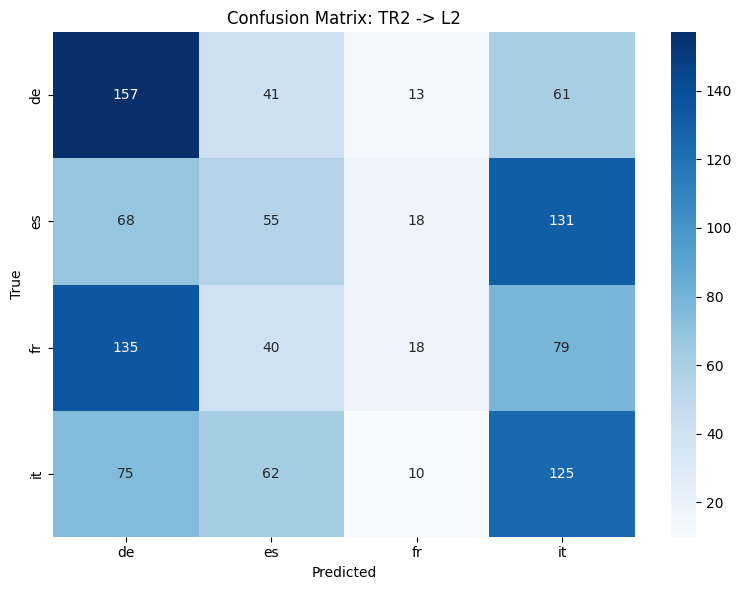

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.32628676470588236,
      de  es  fr   it
 de  157  41  13   61
 es   68  55  18  131
 fr  135  40  18   79
 it   75  62  10  125)

In [ ]:
train_one_test_two(
    TR2,
    L2,
    features,
    title="TR2 -> L2"
)


===== TR2 -> TR1 =====
Test Accuracy: 0.22150735294117646

Classification Report:
               precision    recall  f1-score   support

           0     0.4545    0.1287    0.2006       272
           1     0.1968    0.2279    0.2112       272
           2     0.2607    0.2022    0.2277       272
           3     0.1835    0.3272    0.2351       272

    accuracy                         0.2215      1088
   macro avg     0.2739    0.2215    0.2187      1088
weighted avg     0.2739    0.2215    0.2187      1088


Confusion Matrix:
     de   es  fr   it
de  35  107  59   71
es   9   62  51  150
fr  14   28  55  175
it  19  118  46   89


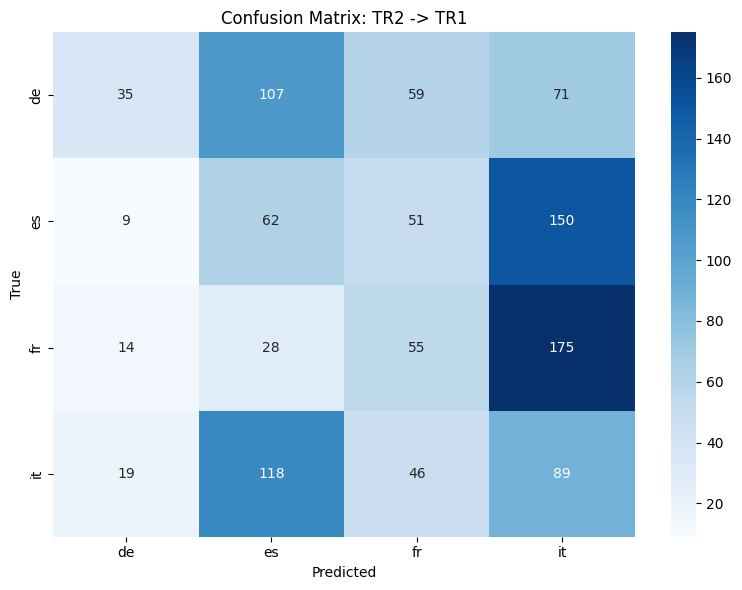

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.22150735294117646,
     de   es  fr   it
 de  35  107  59   71
 es   9   62  51  150
 fr  14   28  55  175
 it  19  118  46   89)

In [ ]:
train_one_test_two(
    TR2,
    TR1,
    features,
    title="TR2 -> TR1"
)


===== L2 -> TR1 =====
Test Accuracy: 0.23805147058823528

Classification Report:
               precision    recall  f1-score   support

           0     0.2684    0.2279    0.2465       272
           1     0.0602    0.0368    0.0457       272
           2     0.2864    0.4632    0.3539       272
           3     0.2430    0.2243    0.2333       272

    accuracy                         0.2381      1088
   macro avg     0.2145    0.2381    0.2198      1088
weighted avg     0.2145    0.2381    0.2198      1088


Confusion Matrix:
     de  es   fr  it
de  62  57  117  36
es  72  10   94  96
fr  80   8  126  58
it  17  91  103  61


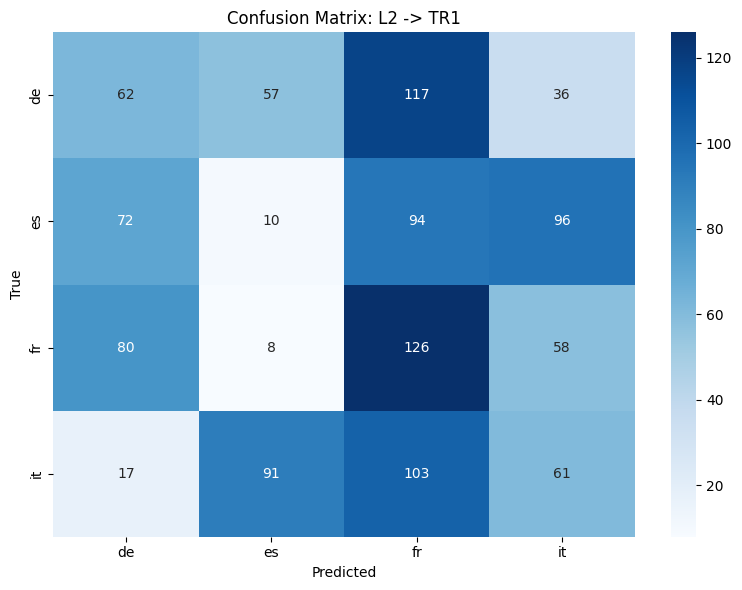

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.23805147058823528,
     de  es   fr  it
 de  62  57  117  36
 es  72  10   94  96
 fr  80   8  126  58
 it  17  91  103  61)

In [ ]:
train_one_test_two(
    L2,
    TR1,
    features,
    title="L2 -> TR1"
)


===== L2 -> TR2 =====
Test Accuracy: 0.28125

Classification Report:
               precision    recall  f1-score   support

           0     0.3750    0.0221    0.0417       272
           1     0.3529    0.0221    0.0415       272
           2     0.2338    0.1728    0.1987       272
           3     0.2892    0.9081    0.4387       272

    accuracy                         0.2812      1088
   macro avg     0.3127    0.2812    0.1802      1088
weighted avg     0.3127    0.2812    0.1802      1088


Confusion Matrix:
     de  es  fr   it
de   6   5  95  166
es   2   6  43  221
fr   4   1  47  220
it   4   5  16  247


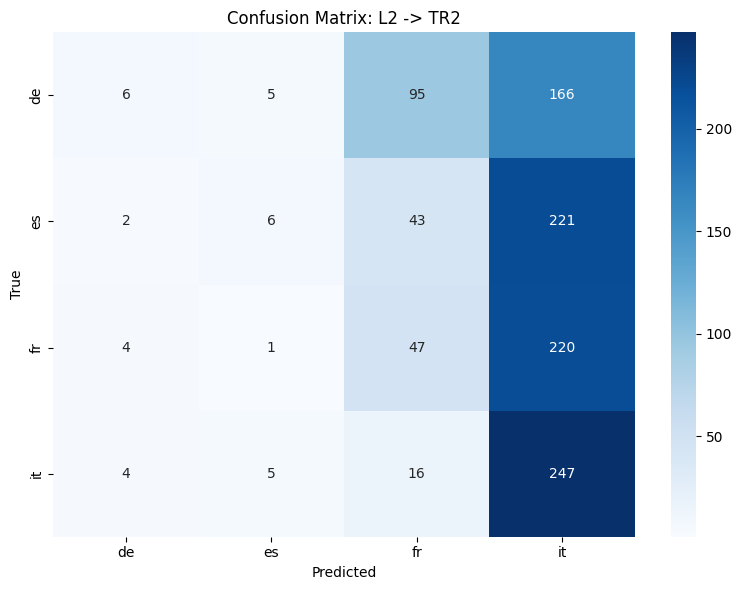

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.28125,
     de  es  fr   it
 de   6   5  95  166
 es   2   6  43  221
 fr   4   1  47  220
 it   4   5  16  247)

In [ ]:
train_one_test_two(
    L2,
    TR2,
    features,
    title="L2 -> TR2"
)

In [ ]:
df_L2_TR2 = pd.concat([L2, TR2], axis=0).reset_index(drop=True)
df_TR1_TR2 = pd.concat([TR1, TR2], axis=0).reset_index(drop=True)
df_TR1_L2 = pd.concat([TR1, L2], axis=0).reset_index(drop=True)

TR1 = TR1.dropna()
L2 = L2.dropna()
TR2 = TR2.dropna()


===== TR1 -> (L2 + TR2) =====
Test Accuracy: 0.25

Classification Report:
               precision    recall  f1-score   support

           0     0.3548    0.0404    0.0726       544
           1     0.2434    0.6783    0.3583       544
           2     0.4000    0.0368    0.0673       544
           3     0.2427    0.2445    0.2436       544

    accuracy                         0.2500      2176
   macro avg     0.3102    0.2500    0.1854      2176
weighted avg     0.3102    0.2500    0.1854      2176


Confusion Matrix:
     de   es  fr   it
de  22  386   6  130
es  13  369  10  152
fr  18  373  20  133
it   9  388  14  133


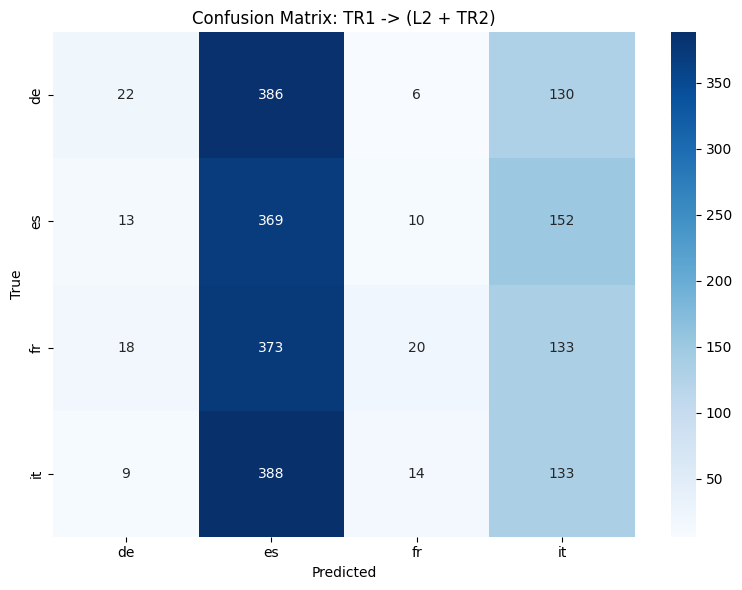

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.25,
     de   es  fr   it
 de  22  386   6  130
 es  13  369  10  152
 fr  18  373  20  133
 it   9  388  14  133)

In [ ]:
train_one_test_two(
    TR1,
    df_L2_TR2,
    features,
    title="TR1 -> (L2 + TR2)"
)


===== L2 -> (TR1 + TR2) =====
Test Accuracy: 0.25965073529411764

Classification Report:
               precision    recall  f1-score   support

           0     0.2753    0.1250    0.1719       544
           1     0.0874    0.0294    0.0440       544
           2     0.2699    0.3180    0.2920       544
           3     0.2787    0.5662    0.3736       544

    accuracy                         0.2597      2176
   macro avg     0.2278    0.2597    0.2204      2176
weighted avg     0.2278    0.2597    0.2204      2176


Confusion Matrix:
     de  es   fr   it
de  68  62  212  202
es  74  16  137  317
fr  84   9  173  278
it  21  96  119  308


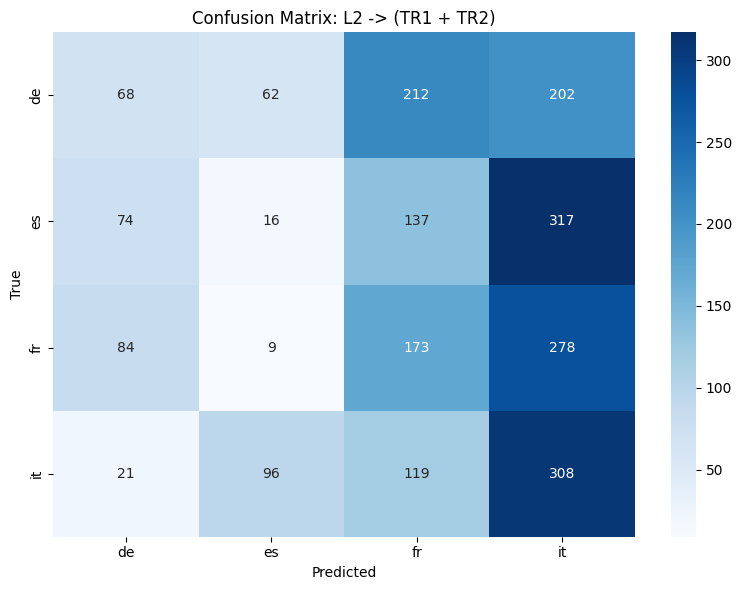

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.25965073529411764,
     de  es   fr   it
 de  68  62  212  202
 es  74  16  137  317
 fr  84   9  173  278
 it  21  96  119  308)

In [ ]:
train_one_test_two(
    L2,
    df_TR1_TR2,
    features,
    title="L2 -> (TR1 + TR2)"
)


===== TR2 -> (TR1 + L2) =====
Test Accuracy: 0.27389705882352944

Classification Report:
               precision    recall  f1-score   support

           0     0.3750    0.3529    0.3636       544
           1     0.2281    0.2151    0.2214       544
           2     0.2704    0.1342    0.1794       544
           3     0.2429    0.3934    0.3004       544

    accuracy                         0.2739      2176
   macro avg     0.2791    0.2739    0.2662      2176
weighted avg     0.2791    0.2739    0.2662      2176


Confusion Matrix:
      de   es  fr   it
de  192  148  72  132
es   77  117  69  281
fr  149   68  73  254
it   94  180  56  214


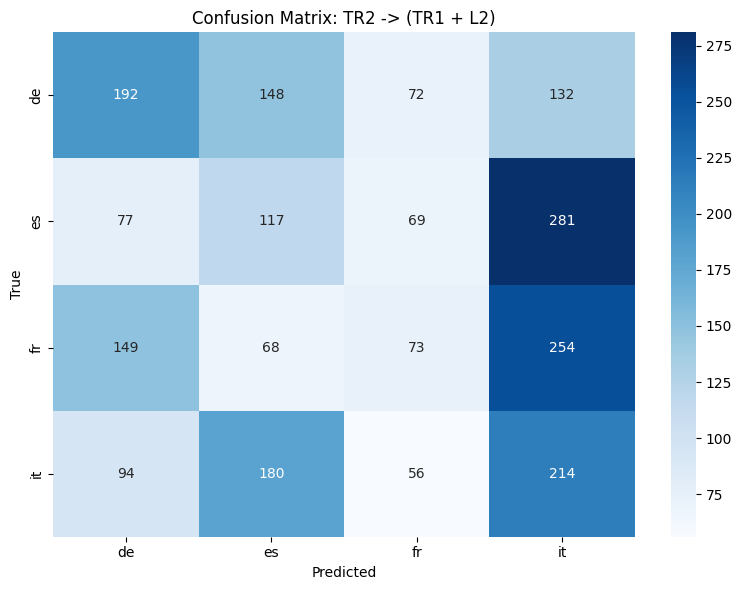

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.27389705882352944,
      de   es  fr   it
 de  192  148  72  132
 es   77  117  69  281
 fr  149   68  73  254
 it   94  180  56  214)

In [ ]:
train_one_test_two(
    TR2,
    df_TR1_L2,
    features,
    title="TR2 -> (TR1 + L2)"
)


===== TR1 -> (L2 + TR2) =====
Test Accuracy: 0.25

Classification Report:
               precision    recall  f1-score   support

           0     0.3548    0.0404    0.0726       544
           1     0.2434    0.6783    0.3583       544
           2     0.4000    0.0368    0.0673       544
           3     0.2427    0.2445    0.2436       544

    accuracy                         0.2500      2176
   macro avg     0.3102    0.2500    0.1854      2176
weighted avg     0.3102    0.2500    0.1854      2176


Confusion Matrix:
     de   es  fr   it
de  22  386   6  130
es  13  369  10  152
fr  18  373  20  133
it   9  388  14  133


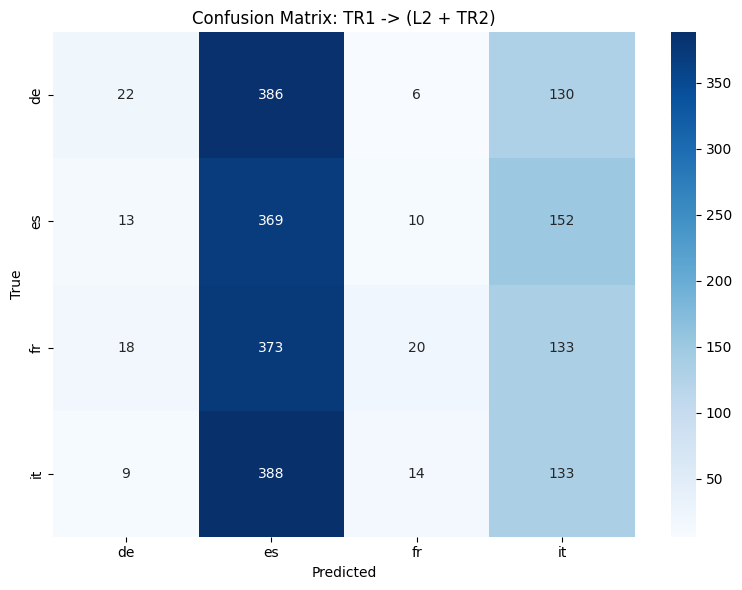

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.25,
     de   es  fr   it
 de  22  386   6  130
 es  13  369  10  152
 fr  18  373  20  133
 it   9  388  14  133)

In [ ]:
train_one_test_two(
    TR1,
    df_L2_TR2,
    features,
    title="TR1 -> (L2 + TR2)"
)


===== L2 -> (TR1 + TR2) =====
Test Accuracy: 0.25965073529411764

Classification Report:
               precision    recall  f1-score   support

           0     0.2753    0.1250    0.1719       544
           1     0.0874    0.0294    0.0440       544
           2     0.2699    0.3180    0.2920       544
           3     0.2787    0.5662    0.3736       544

    accuracy                         0.2597      2176
   macro avg     0.2278    0.2597    0.2204      2176
weighted avg     0.2278    0.2597    0.2204      2176


Confusion Matrix:
     de  es   fr   it
de  68  62  212  202
es  74  16  137  317
fr  84   9  173  278
it  21  96  119  308


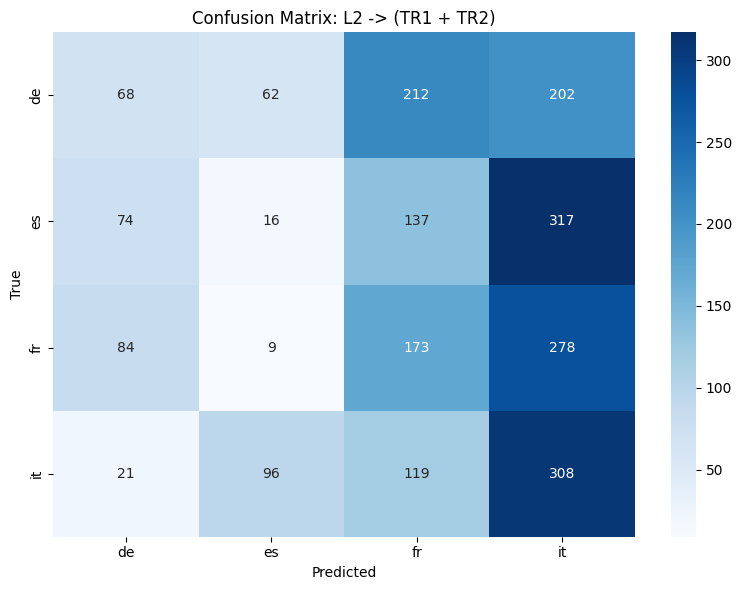

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.25965073529411764,
     de  es   fr   it
 de  68  62  212  202
 es  74  16  137  317
 fr  84   9  173  278
 it  21  96  119  308)

In [ ]:
train_one_test_two(
    L2,
    df_TR1_TR2,
    features,
    title="L2 -> (TR1 + TR2)"
)


===== TR2 -> (TR1 + L2) =====
Test Accuracy: 0.27389705882352944

Classification Report:
               precision    recall  f1-score   support

           0     0.3750    0.3529    0.3636       544
           1     0.2281    0.2151    0.2214       544
           2     0.2704    0.1342    0.1794       544
           3     0.2429    0.3934    0.3004       544

    accuracy                         0.2739      2176
   macro avg     0.2791    0.2739    0.2662      2176
weighted avg     0.2791    0.2739    0.2662      2176


Confusion Matrix:
      de   es  fr   it
de  192  148  72  132
es   77  117  69  281
fr  149   68  73  254
it   94  180  56  214


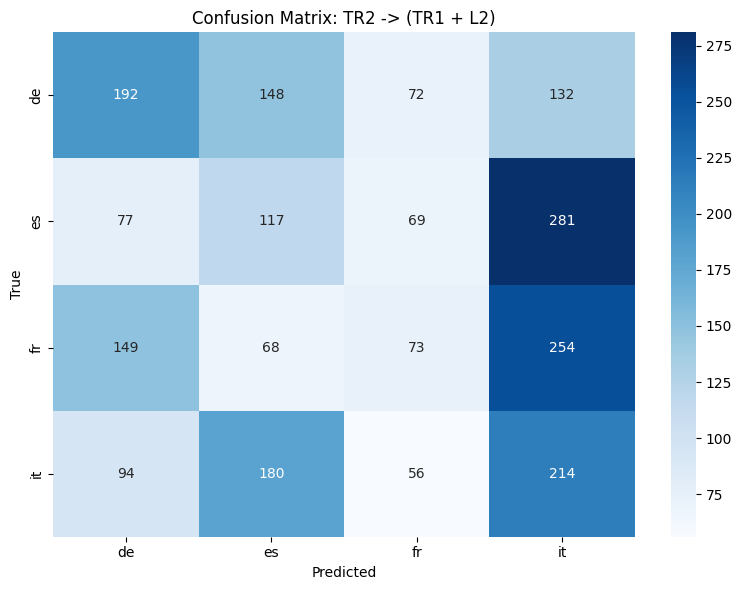

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.27389705882352944,
      de   es  fr   it
 de  192  148  72  132
 es   77  117  69  281
 fr  149   68  73  254
 it   94  180  56  214)

In [ ]:
train_one_test_two(
    TR2,
    df_TR1_L2,
    features,
    title="TR2 -> (TR1 + L2)"
)

# RQ2: Downsampling Every data to smallest available size (ES = 272 in europarl(TR2))

In [ ]:
# smallest sample in Europarl is of 272 (Es) hence downsampling every data
TR1 = (
    TR1
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)

L2 = (
    L2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)


TR2 = (
    TR2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)

### Kmeans

Clustering Accuracy: 0.32536764705882354
Pred   de  es   fr  it
True                  
de    149   0  108  15
es     88   1  109  74
fr    127   0  124  21
it     80   0  112  80

Classification Report:
               precision    recall  f1-score   support

          de     0.3356    0.5478    0.4162       272
          es     1.0000    0.0037    0.0073       272
          fr     0.2737    0.4559    0.3421       272
          it     0.4211    0.2941    0.3463       272

    accuracy                         0.3254      1088
   macro avg     0.5076    0.3254    0.2780      1088
weighted avg     0.5076    0.3254    0.2780      1088



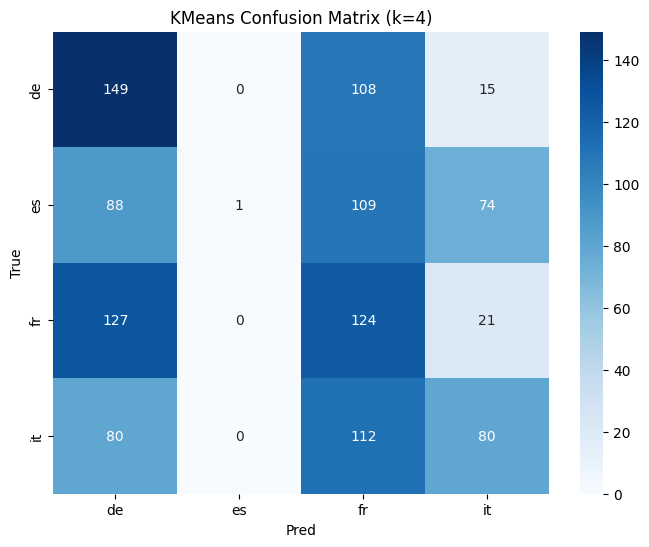

In [ ]:
L2, acc, cm = run_kmeans_evaluation(L2, n_clusters=4, label_col='L1', drop_cols=['L1',"dataset_name"], plot=True)

Clustering Accuracy: 0.3648897058823529
Pred   de  es   fr  it
True                  
de    114  30   75  53
es    107  86   79   0
fr    109  45  118   0
it     34  75   84  79

Classification Report:
               precision    recall  f1-score   support

          de     0.3132    0.4191    0.3585       272
          es     0.3644    0.3162    0.3386       272
          fr     0.3315    0.4338    0.3758       272
          it     0.5985    0.2904    0.3911       272

    accuracy                         0.3649      1088
   macro avg     0.4019    0.3649    0.3660      1088
weighted avg     0.4019    0.3649    0.3660      1088



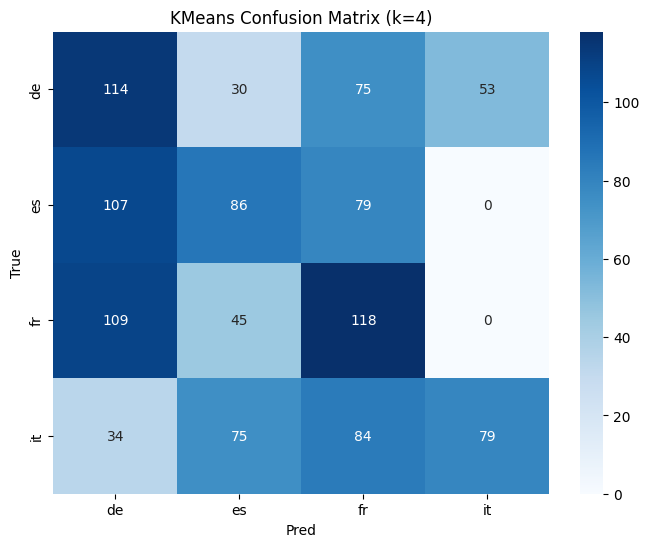

In [ ]:
TR1, acc, cm = run_kmeans_evaluation(TR1, n_clusters=4, label_col='L1', drop_cols=['L1',"dataset_name"], plot=True)

Clustering Accuracy: 0.5211397058823529
Pred   de  es   fr   it
True                   
de    179  70   18    5
es     49  98   66   59
fr     74  34  155    9
it     13  67   57  135

Classification Report:
               precision    recall  f1-score   support

          de     0.5683    0.6581    0.6099       272
          es     0.3643    0.3603    0.3623       272
          fr     0.5236    0.5699    0.5458       272
          it     0.6490    0.4963    0.5625       272

    accuracy                         0.5211      1088
   macro avg     0.5263    0.5211    0.5201      1088
weighted avg     0.5263    0.5211    0.5201      1088



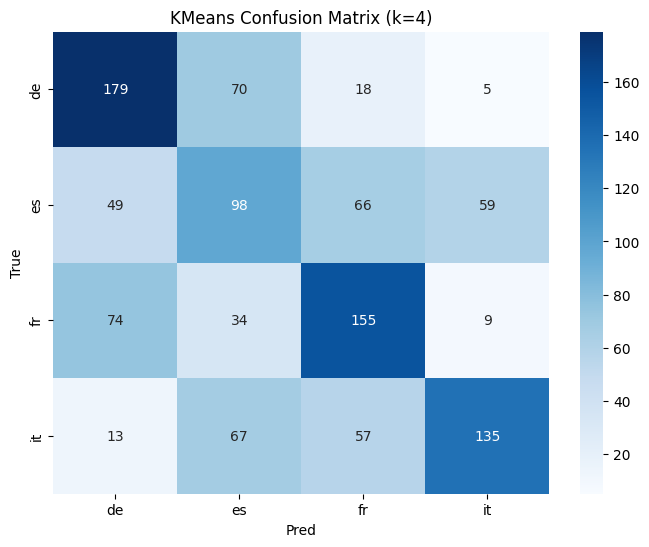

In [ ]:

TR2, acc, cm = run_kmeans_evaluation(TR2, n_clusters=4, label_col='L1', drop_cols=['L1',"dataset_name"], plot=True)

###NN


===== MLP Classification of L2 dataset(Test set) =====
Test Accuracy: 0.3302752293577982

Classification Report:
               precision    recall  f1-score   support

          de     0.3934    0.4364    0.4138        55
          es     0.2653    0.2407    0.2524        54
          fr     0.3226    0.3636    0.3419        55
          it     0.3261    0.2778    0.3000        54

    accuracy                         0.3303       218
   macro avg     0.3269    0.3296    0.3270       218
weighted avg     0.3271    0.3303    0.3275       218


Confusion matrix:
[[24 16 13  2]
 [12 13 13 16]
 [16  6 20 13]
 [ 9 14 16 15]]


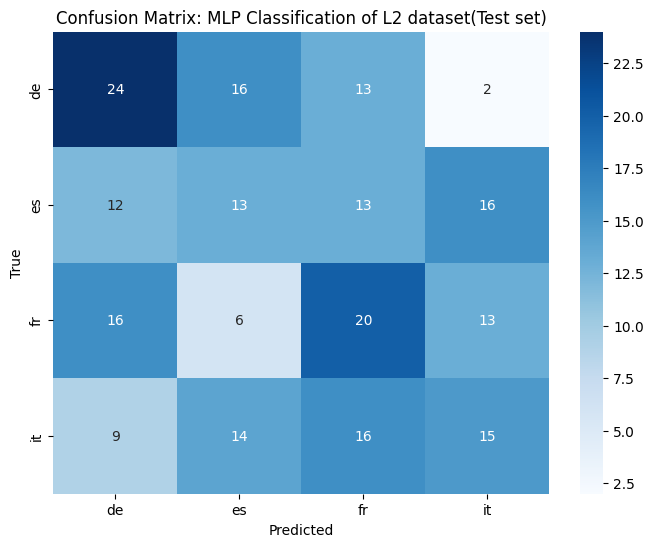

In [ ]:
features = L2.drop(columns=['L1',"dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(L2, features, label_col="L1", title="MLP Classification of L2 dataset(Test set)")


===== MLP Classification of TR1 dataset(Test set) =====
Test Accuracy: 0.5137614678899083

Classification Report:
               precision    recall  f1-score   support

          de     0.5094    0.4909    0.5000        55
          es     0.5217    0.4444    0.4800        54
          fr     0.5246    0.5818    0.5517        55
          it     0.5000    0.5370    0.5179        54

    accuracy                         0.5138       218
   macro avg     0.5139    0.5136    0.5124       218
weighted avg     0.5140    0.5138    0.5125       218


Confusion matrix:
[[27  7  3 18]
 [ 8 24 15  7]
 [12  7 32  4]
 [ 6  8 11 29]]


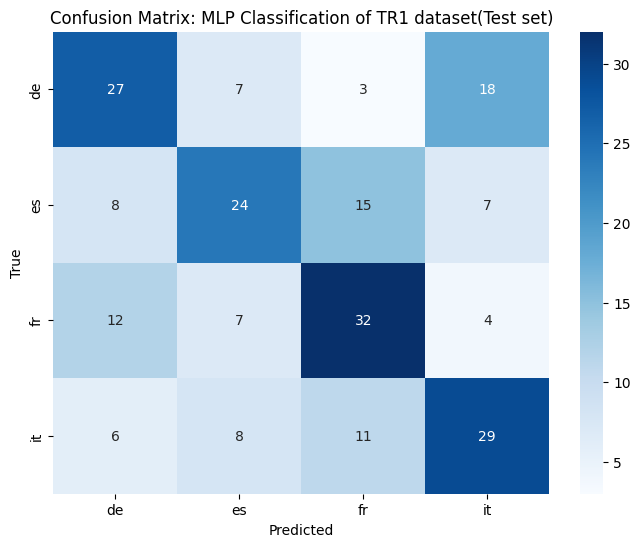

In [ ]:
features = TR1.drop(columns=['L1',"dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(TR1, features, label_col="L1", title="MLP Classification of TR1 dataset(Test set)")


===== MLP Classification of TR2 dataset(Test set) =====
Test Accuracy: 0.7706422018348624

Classification Report:
               precision    recall  f1-score   support

          de     0.8448    0.8909    0.8673        55
          es     0.6792    0.6667    0.6729        54
          fr     0.7593    0.7455    0.7523        55
          it     0.7925    0.7778    0.7850        54

    accuracy                         0.7706       218
   macro avg     0.7689    0.7702    0.7694       218
weighted avg     0.7692    0.7706    0.7697       218


Confusion matrix:
[[49  1  4  1]
 [ 4 36  6  8]
 [ 3  9 41  2]
 [ 2  7  3 42]]


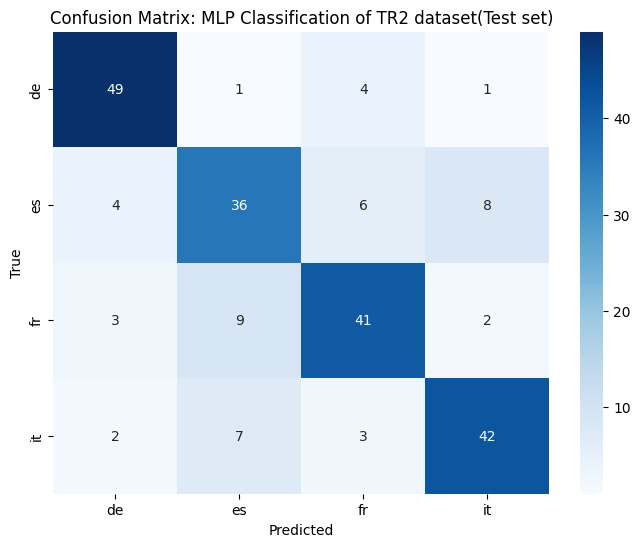

In [ ]:
features = TR2.drop(columns=['L1',"dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(TR2, features, label_col="L1", title="MLP Classification of TR2 dataset(Test set)")

### Combining after downsampling

In [ ]:
TR1["dataset_name"] = "TR1"
TR2["dataset_name"] = "TR2"
L2["dataset_name"] = "L2"
df = pd.concat([TR1, L2, TR2], axis=0, ignore_index=True)

Clustering Accuracy: 0.2867647058823529
Pred  de  es   fr   it
True                  
de     0   0  435  381
es     0   0  494  322
fr     0   0  498  318
it     0   0  378  438

Classification Report:
               precision    recall  f1-score   support

          de     0.0000    0.0000    0.0000       816
          es     0.0000    0.0000    0.0000       816
          fr     0.2759    0.6103    0.3800       816
          it     0.3002    0.5368    0.3851       816

    accuracy                         0.2868      3264
   macro avg     0.1440    0.2868    0.1913      3264
weighted avg     0.1440    0.2868    0.1913      3264



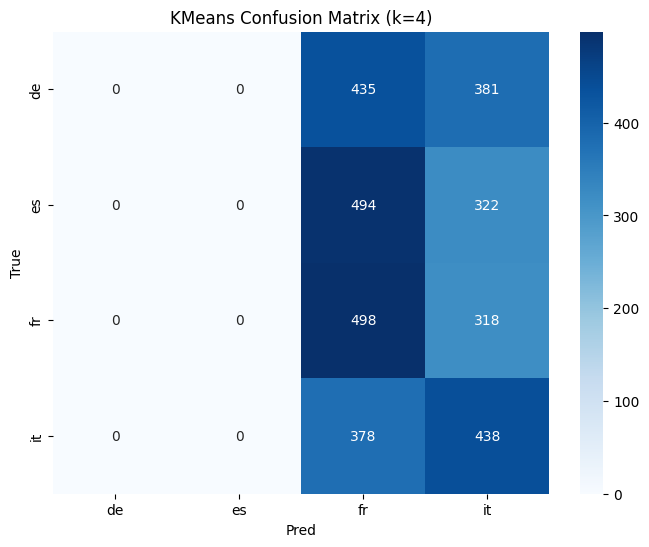

In [ ]:
df, acc, cm = run_kmeans_evaluation(df, n_clusters=4, label_col='L1', drop_cols=['L1',"dataset_name"], plot=True)


===== MLP Classification of all dataset(Test set) =====
Test Accuracy: 0.5604900459418071

Classification Report:
               precision    recall  f1-score   support

          de     0.5767    0.5767    0.5767       163
          es     0.5441    0.4540    0.4950       163
          fr     0.5642    0.6159    0.5889       164
          it     0.5543    0.5951    0.5740       163

    accuracy                         0.5605       653
   macro avg     0.5598    0.5604    0.5586       653
weighted avg     0.5598    0.5605    0.5587       653


Confusion matrix:
[[ 94  18  19  32]
 [ 23  74  36  30]
 [ 30  17 101  16]
 [ 16  27  23  97]]


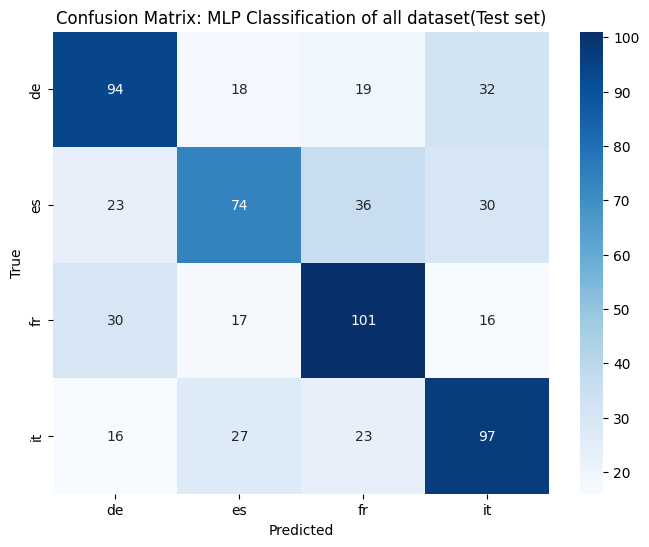

In [ ]:
features = df.drop(columns=['L1',"dataset_name"]).select_dtypes(include=[np.number]).columns
df = df.dropna()
mlp_model, acc, cm = run_nn(df, features, label_col="L1", title="MLP Classification of all dataset(Test set)")
#note: only test accuracy is here.

# RQ4: Do K-means with 3 clusters taking one language out each time

In [ ]:
def leave_one_language_out_kmeans(df, label_col='L1', drop_cols=None, plot=False):

    results = {}
    languages = df[label_col].unique()

    for lang in languages:
        print("\n" + "="*50)
        print(f"Removing language: {lang}")
        print("="*50)

        # Filter out one language
        df_subset = df[df[label_col] != lang].copy()

        # Run KMeans on remaining languages
        _, acc, cm = run_kmeans_evaluation(
            df_subset,
            n_clusters=len(languages) - 1,
            label_col=label_col,
            drop_cols=drop_cols,
            plot=plot
        )

        # Store results
        results[lang] = {
            "accuracy": acc,
            "confusion_matrix": cm
        }

    return results



Removing language: de
Clustering Accuracy: 0.3741830065359477
Pred   es  fr   it
True              
es    277   0  539
fr    266   0  550
it    177   0  639

Classification Report:
               precision    recall  f1-score   support

          es     0.3847    0.3395    0.3607       816
          fr     0.0000    0.0000    0.0000       816
          it     0.3698    0.7831    0.5024       816

    accuracy                         0.3742      2448
   macro avg     0.2515    0.3742    0.2877      2448
weighted avg     0.2515    0.3742    0.2877      2448



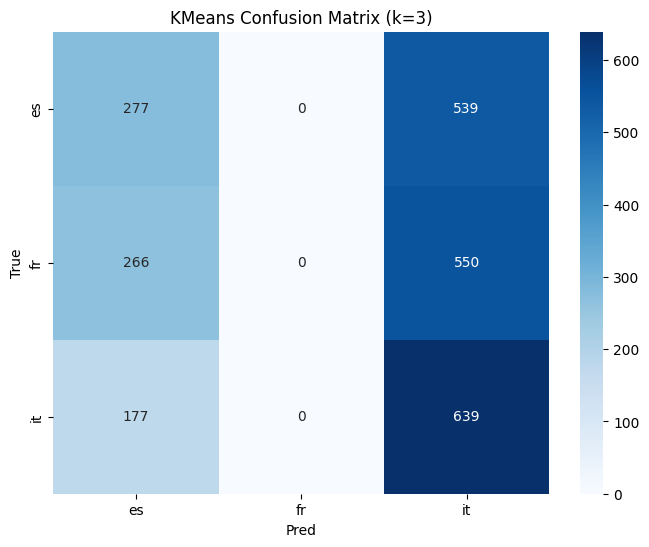


Removing language: es
Clustering Accuracy: 0.3741830065359477
Pred  de   fr   it
True              
de     0  214  602
fr     0  263  553
it     0  163  653

Classification Report:
               precision    recall  f1-score   support

          de     0.0000    0.0000    0.0000       816
          fr     0.4109    0.3223    0.3613       816
          it     0.3612    0.8002    0.4977       816

    accuracy                         0.3742      2448
   macro avg     0.2574    0.3742    0.2863      2448
weighted avg     0.2574    0.3742    0.2863      2448



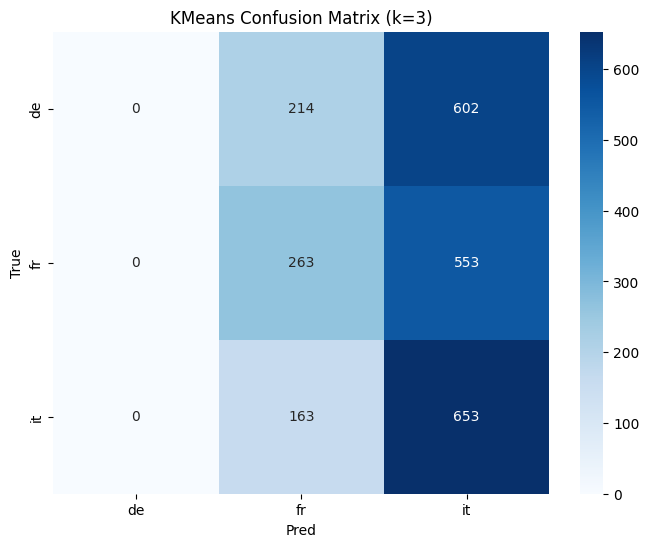


Removing language: fr
Clustering Accuracy: 0.37459150326797386
Pred  de   es   it
True              
de     0  217  599
es     0  276  540
it     0  175  641

Classification Report:
               precision    recall  f1-score   support

          de     0.0000    0.0000    0.0000       816
          es     0.4132    0.3382    0.3720       816
          it     0.3601    0.7855    0.4938       816

    accuracy                         0.3746      2448
   macro avg     0.2578    0.3746    0.2886      2448
weighted avg     0.2578    0.3746    0.2886      2448



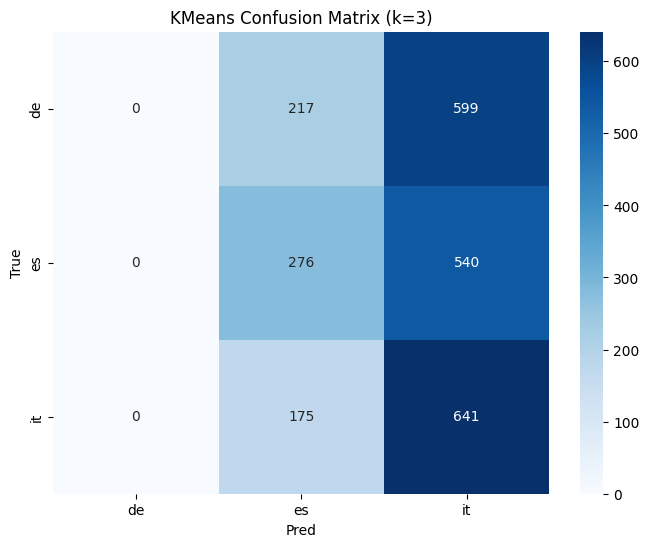


Removing language: it
Clustering Accuracy: 0.35866013071895425
Pred  de   es   fr
True              
de    52  216  548
es     0  274  542
fr     0  264  552

Classification Report:
               precision    recall  f1-score   support

          de     1.0000    0.0637    0.1198       816
          es     0.3634    0.3358    0.3490       816
          fr     0.3362    0.6765    0.4491       816

    accuracy                         0.3587      2448
   macro avg     0.5665    0.3587    0.3060      2448
weighted avg     0.5665    0.3587    0.3060      2448



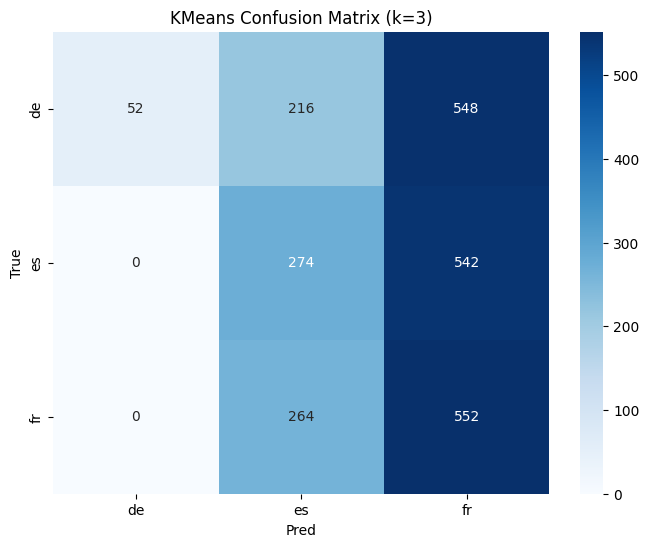

In [ ]:

results = leave_one_language_out_kmeans(
df,
label_col='L1',
drop_cols=['L1',"dataset_name"],
plot=True
)


Removing language: de
Clustering Accuracy: 0.6515522875816994
Pred   L2  TR1  TR2
True               
L2    812    4    0
TR1    33  783    0
TR2   804   12    0

Classification Report:
               precision    recall  f1-score   support

          L2     0.4924    0.9951    0.6588       816
         TR1     0.9800    0.9596    0.9697       816
         TR2     0.0000    0.0000    0.0000       816

    accuracy                         0.6516      2448
   macro avg     0.4908    0.6516    0.5428      2448
weighted avg     0.4908    0.6516    0.5428      2448



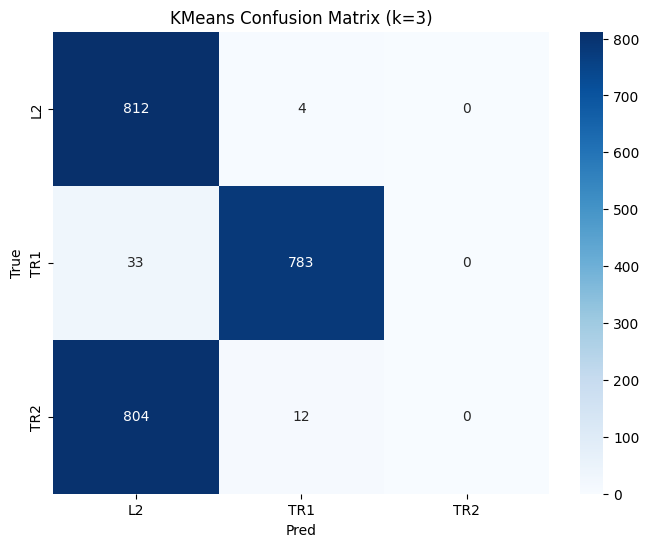


Removing language: es
Clustering Accuracy: 0.6450163398692811
Pred   L2  TR1  TR2
True               
L2    813    3    0
TR1    50  766    0
TR2   813    3    0

Classification Report:
               precision    recall  f1-score   support

          L2     0.4851    0.9963    0.6525       816
         TR1     0.9922    0.9387    0.9647       816
         TR2     0.0000    0.0000    0.0000       816

    accuracy                         0.6450      2448
   macro avg     0.4924    0.6450    0.5391      2448
weighted avg     0.4924    0.6450    0.5391      2448



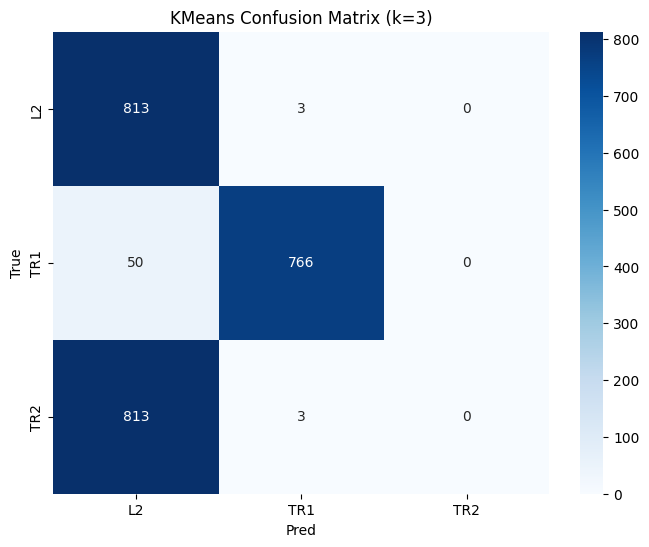


Removing language: fr
Clustering Accuracy: 0.6527777777777778
Pred   L2  TR1  TR2
True               
L2    813    3    0
TR1    31  785    0
TR2   804   12    0

Classification Report:
               precision    recall  f1-score   support

          L2     0.4933    0.9963    0.6599       816
         TR1     0.9812    0.9620    0.9715       816
         TR2     0.0000    0.0000    0.0000       816

    accuracy                         0.6528      2448
   macro avg     0.4915    0.6528    0.5438      2448
weighted avg     0.4915    0.6528    0.5438      2448



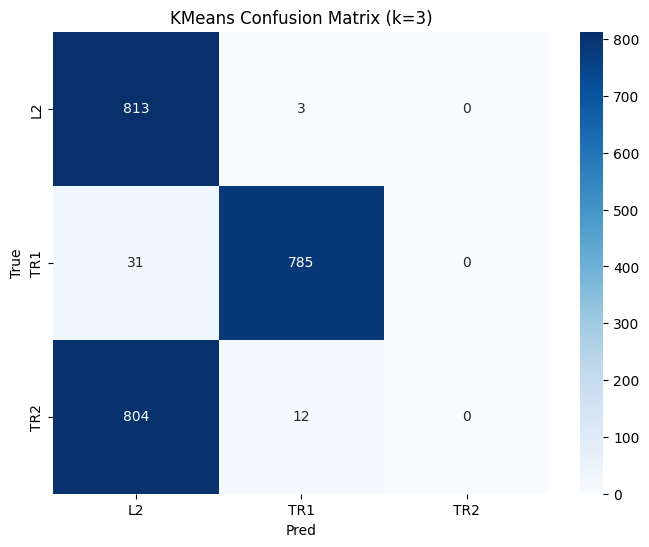


Removing language: it
Clustering Accuracy: 0.6576797385620915
Pred   L2  TR1  TR2
True               
L2    813    3    0
TR1    19  797    0
TR2   810    6    0

Classification Report:
               precision    recall  f1-score   support

          L2     0.4951    0.9963    0.6615       816
         TR1     0.9888    0.9767    0.9827       816
         TR2     0.0000    0.0000    0.0000       816

    accuracy                         0.6577      2448
   macro avg     0.4947    0.6577    0.5481      2448
weighted avg     0.4947    0.6577    0.5481      2448



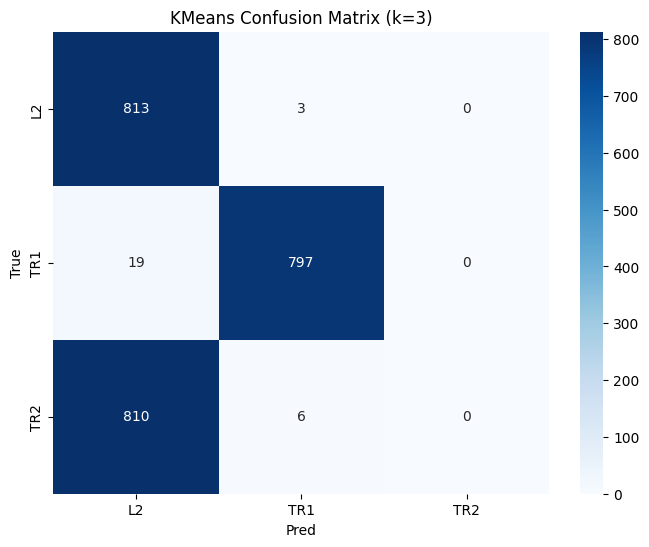

In [ ]:
def leave_one_language_out_kmeans_dataset(df, label_col='L1', drop_cols=None, plot=False):

    results = {}
    languages = df[label_col].unique()

    for lang in languages:
        print("\n" + "="*50)
        print(f"Removing language: {lang}")
        print("="*50)

        # Filter out one language
        df_subset = df[df[label_col] != lang].copy()

        # Run KMeans on remaining languages
        _, acc, cm = run_kmeans_evaluation(
            df_subset,
            n_clusters = df_subset['dataset_name'].nunique(),
            label_col='dataset_name',
            drop_cols=drop_cols,
            plot=plot
        )

        # Store results
        results[lang] = {
            "accuracy": acc,
            "confusion_matrix": cm
        }

    return results


results = leave_one_language_out_kmeans_dataset(
df,
label_col='L1',
drop_cols=['L1',"dataset_name"],
plot=True
)

## L2


Removing language: de
Clustering Accuracy: 0.3897058823529412
Pred  es   fr  it
True             
es    56  216   0
fr    10  262   0
it    54  218   0

Classification Report:
               precision    recall  f1-score   support

          es     0.4667    0.2059    0.2857       272
          fr     0.3764    0.9632    0.5413       272
          it     0.0000    0.0000    0.0000       272

    accuracy                         0.3897       816
   macro avg     0.2810    0.3897    0.2757       816
weighted avg     0.2810    0.3897    0.2757       816



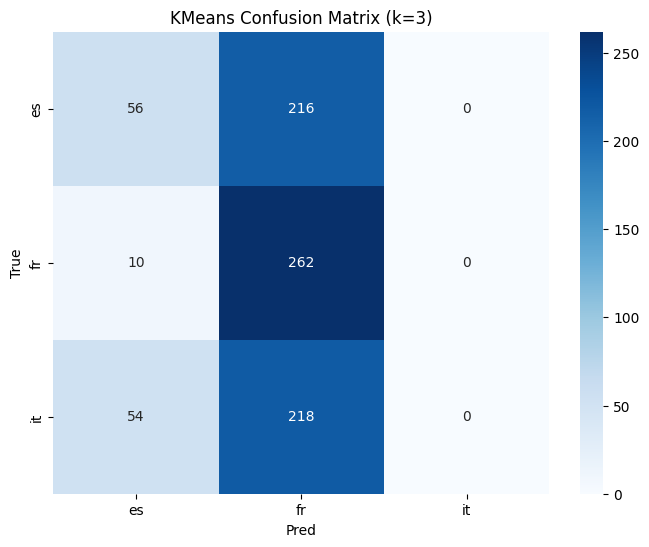


Removing language: es
Clustering Accuracy: 0.4375
Pred   de   fr   it
True               
de    132  115   25
fr    110  124   38
it     71  100  101

Classification Report:
               precision    recall  f1-score   support

          de     0.4217    0.4853    0.4513       272
          fr     0.3658    0.4559    0.4059       272
          it     0.6159    0.3713    0.4633       272

    accuracy                         0.4375       816
   macro avg     0.4678    0.4375    0.4402       816
weighted avg     0.4678    0.4375    0.4402       816



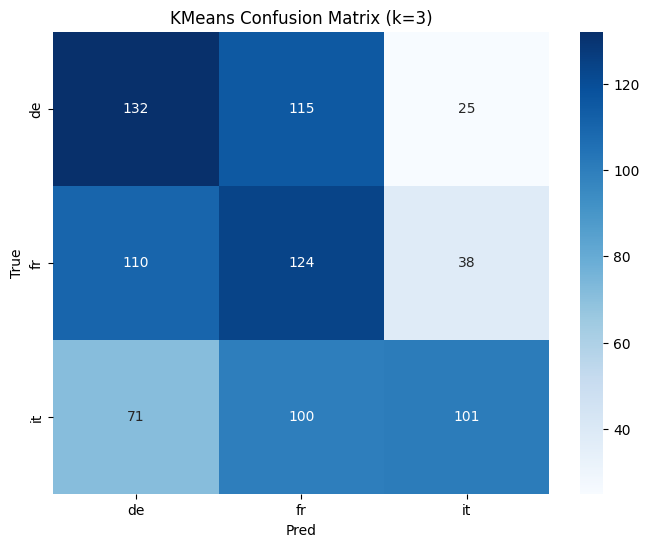


Removing language: fr
Clustering Accuracy: 0.4387254901960784
Pred   de  es   it
True              
de    248   0   24
es    163   3  106
it    165   0  107

Classification Report:
               precision    recall  f1-score   support

          de     0.4306    0.9118    0.5849       272
          es     1.0000    0.0110    0.0218       272
          it     0.4515    0.3934    0.4204       272

    accuracy                         0.4387       816
   macro avg     0.6273    0.4387    0.3424       816
weighted avg     0.6273    0.4387    0.3424       816



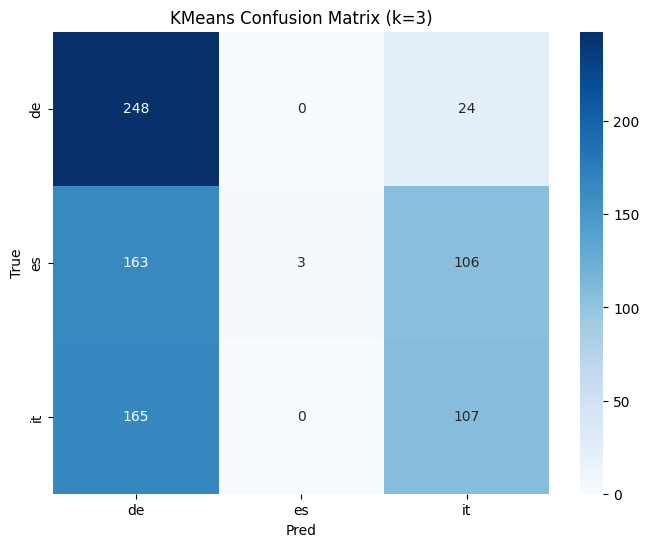


Removing language: it
Clustering Accuracy: 0.4362745098039216
Pred   de   es  fr
True              
de    208   64   0
es    124  148   0
fr    197   75   0

Classification Report:
               precision    recall  f1-score   support

          de     0.3932    0.7647    0.5194       272
          es     0.5157    0.5441    0.5295       272
          fr     0.0000    0.0000    0.0000       272

    accuracy                         0.4363       816
   macro avg     0.3030    0.4363    0.3496       816
weighted avg     0.3030    0.4363    0.3496       816



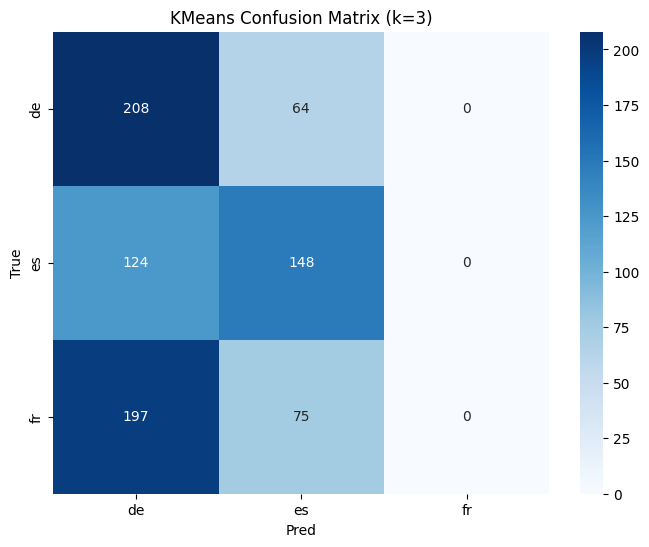

In [ ]:

results = leave_one_language_out_kmeans(
L2,
label_col='L1',
drop_cols=['L1',"dataset_name"],
plot=True   # or False if too many plots
)

## TR1


Removing language: de
Clustering Accuracy: 0.49387254901960786
Pred   es   fr  it
True              
es    111  161   0
fr     59  213   0
it     86  107  79

Classification Report:
               precision    recall  f1-score   support

          es     0.4336    0.4081    0.4205       272
          fr     0.4428    0.7831    0.5657       272
          it     1.0000    0.2904    0.4501       272

    accuracy                         0.4939       816
   macro avg     0.6255    0.4939    0.4788       816
weighted avg     0.6255    0.4939    0.4788       816



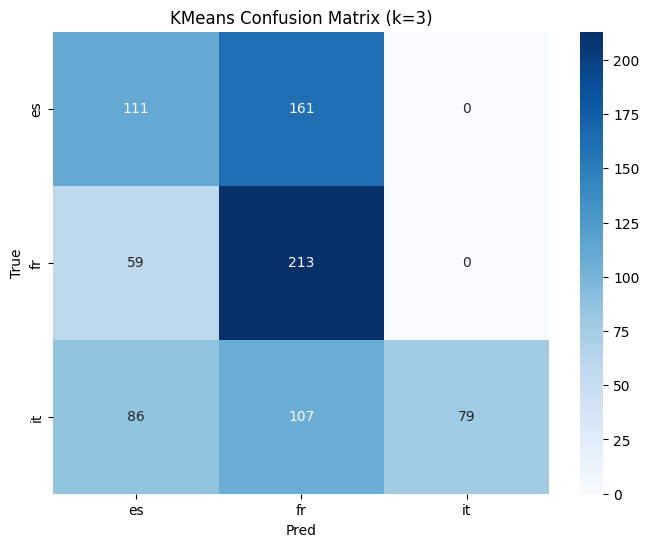


Removing language: es
Clustering Accuracy: 0.4583333333333333
Pred  de   fr   it
True              
de     0  172  100
fr     0  199   73
it     0   97  175

Classification Report:
               precision    recall  f1-score   support

          de     0.0000    0.0000    0.0000       272
          fr     0.4252    0.7316    0.5378       272
          it     0.5029    0.6434    0.5645       272

    accuracy                         0.4583       816
   macro avg     0.3094    0.4583    0.3675       816
weighted avg     0.3094    0.4583    0.3675       816



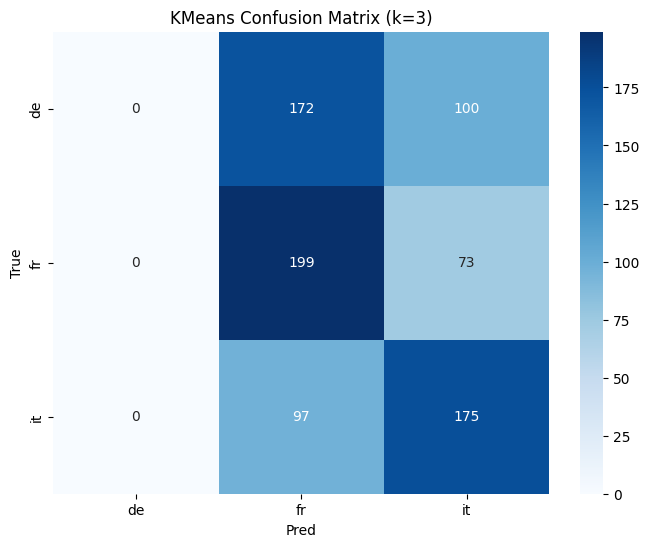


Removing language: fr
Clustering Accuracy: 0.4742647058823529
Pred   de   es  it
True              
de    171   48  53
es    135  137   0
it     98   95  79

Classification Report:
               precision    recall  f1-score   support

          de     0.4233    0.6287    0.5059       272
          es     0.4893    0.5037    0.4964       272
          it     0.5985    0.2904    0.3911       272

    accuracy                         0.4743       816
   macro avg     0.5037    0.4743    0.4645       816
weighted avg     0.5037    0.4743    0.4645       816



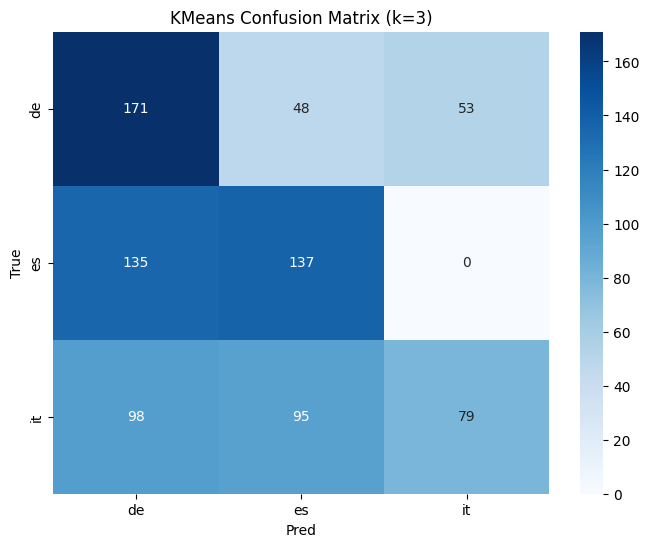


Removing language: it
Clustering Accuracy: 0.45465686274509803
Pred   de   es  fr
True              
de    210   62   0
es    111  161   0
fr    140  132   0

Classification Report:
               precision    recall  f1-score   support

          de     0.4555    0.7721    0.5730       272
          es     0.4535    0.5919    0.5136       272
          fr     0.0000    0.0000    0.0000       272

    accuracy                         0.4547       816
   macro avg     0.3030    0.4547    0.3622       816
weighted avg     0.3030    0.4547    0.3622       816



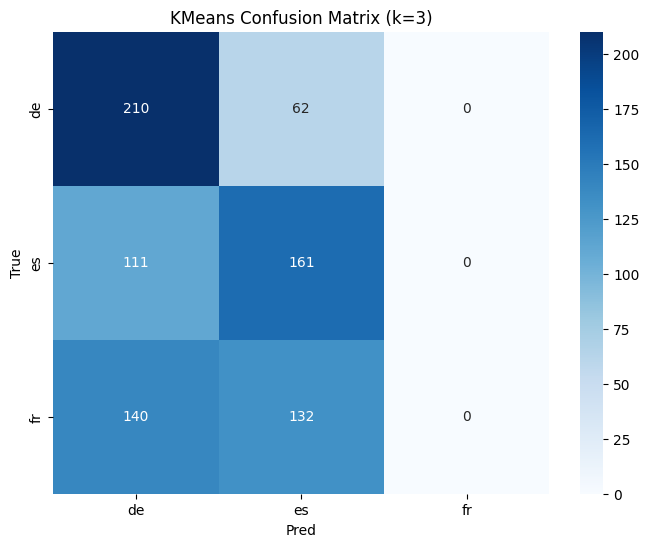

In [ ]:

results = leave_one_language_out_kmeans(
TR1,
label_col='L1',
drop_cols=['L1',"dataset_name"],
plot=True   # or False if too many plots
)

## TR2


Removing language: de
Clustering Accuracy: 0.5747549019607843
Pred  es   fr   it
True              
es    84   98   90
fr    44  212   16
it    38   61  173

Classification Report:
               precision    recall  f1-score   support

          es     0.5060    0.3088    0.3836       272
          fr     0.5714    0.7794    0.6594       272
          it     0.6201    0.6360    0.6279       272

    accuracy                         0.5748       816
   macro avg     0.5658    0.5748    0.5570       816
weighted avg     0.5658    0.5748    0.5570       816



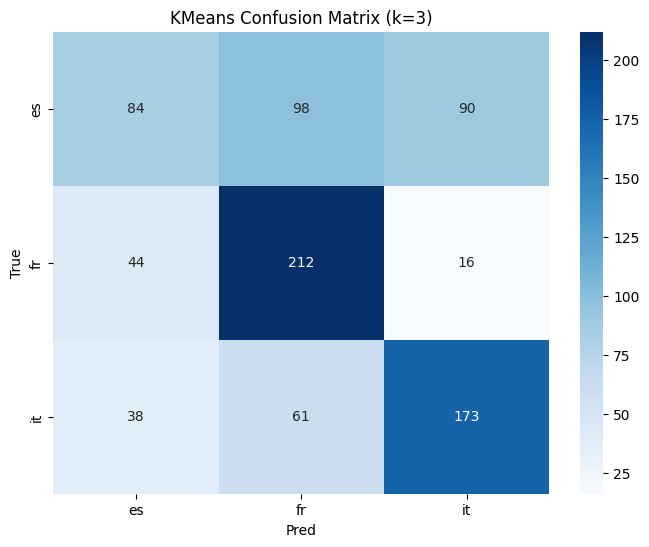


Removing language: es
Clustering Accuracy: 0.6887254901960784
Pred   de   fr   it
True               
de    223   41    8
fr     87  173   12
it     33   73  166

Classification Report:
               precision    recall  f1-score   support

          de     0.6501    0.8199    0.7252       272
          fr     0.6028    0.6360    0.6190       272
          it     0.8925    0.6103    0.7249       272

    accuracy                         0.6887       816
   macro avg     0.7151    0.6887    0.6897       816
weighted avg     0.7151    0.6887    0.6897       816



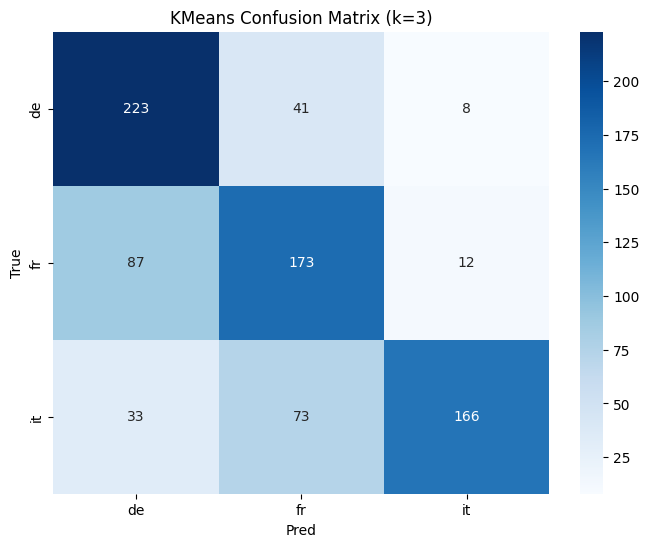


Removing language: fr
Clustering Accuracy: 0.5796568627450981
Pred   de   es   it
True               
de    204   64    4
es     89  119   64
it     33   89  150

Classification Report:
               precision    recall  f1-score   support

          de     0.6258    0.7500    0.6823       272
          es     0.4375    0.4375    0.4375       272
          it     0.6881    0.5515    0.6122       272

    accuracy                         0.5797       816
   macro avg     0.5838    0.5797    0.5773       816
weighted avg     0.5838    0.5797    0.5773       816



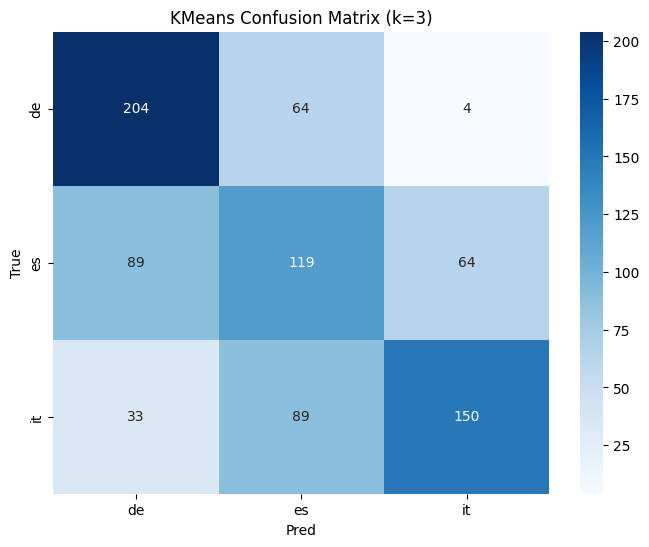


Removing language: it
Clustering Accuracy: 0.6262254901960784
Pred   de   es   fr
True               
de    213   19   40
es     75  125   72
fr     76   23  173

Classification Report:
               precision    recall  f1-score   support

          de     0.5852    0.7831    0.6698       272
          es     0.7485    0.4596    0.5695       272
          fr     0.6070    0.6360    0.6212       272

    accuracy                         0.6262       816
   macro avg     0.6469    0.6262    0.6202       816
weighted avg     0.6469    0.6262    0.6202       816



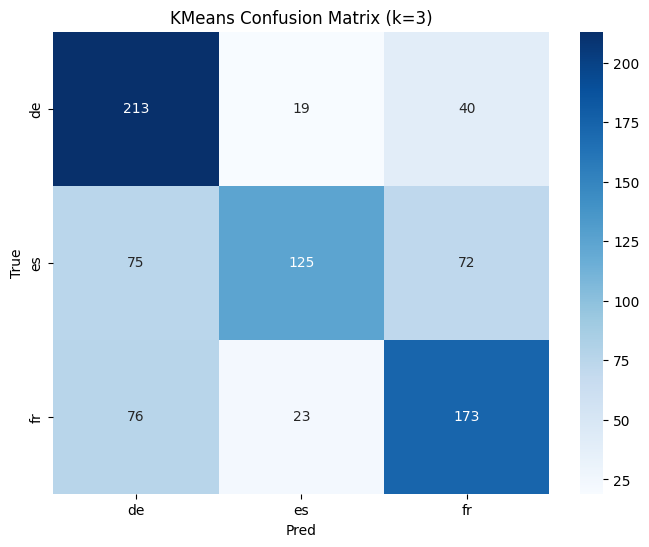

In [ ]:

results = leave_one_language_out_kmeans(
TR2,
label_col='L1',
drop_cols=['L1',"dataset_name"],
plot=True   # or False if too many plots
)

### Issue: always tries to make 2 clusters instead of 3.

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

def plot_pca(df, label_col='L1', drop_cols=None):

    df = df.dropna().copy()

    # Labels
    y = df[label_col].values

    # Features
    if drop_cols is not None:
        X = df.drop(drop_cols, axis=1).values
    else:
        X = df.drop(columns=[label_col]).values

    # Scale (VERY important for PCA)
    X = StandardScaler().fit_transform(X)

    # Apply PCA → 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Create dataframe for plotting
    plot_df = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1],
        'Language': y
    })

    # Plot
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Language', alpha=0.7)
    plt.title('PCA Projection of Languages')
    plt.legend()
    plt.show()

    # Explained variance (important!)
    print("Explained variance ratio:", pca.explained_variance_ratio_)

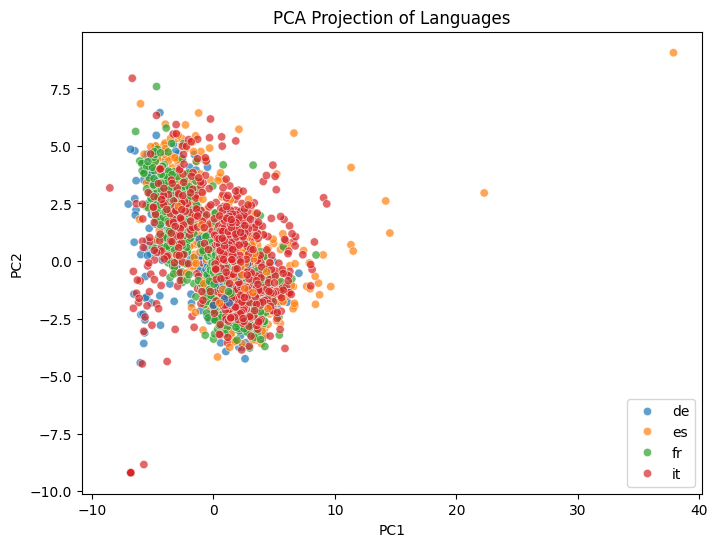

Explained variance ratio: [0.23002862 0.16025487]


In [ ]:
plot_pca(
    df,
    label_col='L1',
    drop_cols=['L1',"dataset_name"]
)